# P5a · Socioeconomic Characterization of Rural Demographic Groups
## *RURIMESCAPE — Paper 1, Step 5a*

---

**Paper:** Rural Migration and Land Use in Spain — Paper 1  
**Step:** 5a — Socioeconomic characterization and descriptive comparative analysis  
**Author:** Juan Zotes  
**Last updated:** 2026-04

---

### Context and purpose

Building on the behavioural classification and spatial analysis from Steps 3 and 4,
this notebook characterises the **socioeconomic conditions** associated with the four
demographic behavioural groups identified for Spanish rural municipalities:

| Group | Definition |
|-------|------------|
| **Grows in both** | Sustained dynamisers — positive growth in Period A (2010-2017) and Period B (2018-2025) |
| **Reverses in B** | Reverters — declined in A, recovered in B (primary neo-rural signal) |
| **Loses in B** | Gained in A, declined in B |
| **Structural depopulation** | Declined in both periods — reference group for models in p5b |

The analysis covers **all six Goerlich typologies**. Paper 1 analysis focuses on
Rural-Remote and Rural-Accessible, filtered via DuckDB SQL at the point of use.
The full 8,132-municipality master dataset is preserved for Paper 2/3 reuse.

---

### ⚠️ Important note on variable temporality

SIDAMUN variables are from the **2023 reference snapshot** (downloaded February 2026).
They are **contemporaneous with or posterior to Period B (2018–2025)** and should be
interpreted as characterising the **current state** of each group, not as pre-turning-point
baseline conditions. This limitation is explicitly stated in the paper methodology section.

---

### Analytical structure

| Section | Content |
|---------|--------|
| 0 | Environment, paths, constants |
| 1 | **DuckDB setup** — first use of SQL in this project |
| 2 | Data loading and master dataset construction via DuckDB |
| 3 | Variable exploration: missings, candidate selection, Spearman correlation |
| 4 | Descriptive statistics — medians by group and typology |
| 5 | Kruskal-Wallis tests + Dunn post-hoc (Bonferroni correction) |
| 6 | Figures — boxplots by group and variable |
| 7 | Export outputs |
| 8 | Interpretation notes |

---

### Inputs

| File | Location | Description |
|------|----------|-------------|
| `p4_spatial_hotspots.gpkg` — layer `lisa_results_all` | `data/spatial/processed/` | **All 8,132 Spanish municipalities** with behavioural groups and LISA results (all 6 Goerlich typologies) |
| `SIDAMUN_MITERD.xlsx` | `data/services/raw/` | Socioeconomic variables by municipality (MITERD, 2023) |

### Join strategy

```
lisa_results_all  (8,132 rows, single load)
  LEFT JOIN SIDAMUN  →  master dataset (8,132 rows)

All typology filtering done via DuckDB SQL at point of use:
  WHERE tipo_goerlich = 'Rural - Remoto'          → Rural-Remote analysis
  WHERE tipo_goerlich = 'Rural - Accesible'        → Rural-Accessible analysis
  WHERE tipo_goerlich IN ('Rural - Remoto', ...)   → combined rural
  No filter                                        → all typologies (Paper 2/3)
```

### Outputs

| File | Location | Description |
|------|----------|-------------|
| `p5a_master_dataset.csv` | `data/demography/derived/paper1/` | **All 8,132 municipalities**, all typologies. Reusable for Paper 2/3. |
| `p5a_rural_analysis_dataset.csv` | `data/demography/derived/paper1/` | Rural subset (6,723 municipalities) filtered from master, selected variables. Input for p5b. |
| `p5a_selected_variables.csv` | `data/demography/derived/paper1/` | Variable selection log: missings, correlation with response, keep/drop decision |
| `p5a_descriptive_stats.csv` | `data/demography/derived/paper1/` | Medians by group × typology for all selected variables |
| `p5a_kruskal_wallis_results.csv` | `data/demography/derived/paper1/` | KW test results per variable and typology |
| `p5a_dunn_results.csv` | `data/demography/derived/paper1/` | Dunn post-hoc pairwise results (Bonferroni-corrected) |
| `figures/p5a/` | `figures/` | Boxplot figures per variable block |


---
## 0 · Environment, paths, constants

In [1]:
"""
Notebook  : p5a_socioeconomic_characterization.ipynb
Author    : Juan Zotes
Created   : 2026-04

Purpose:
    Socioeconomic characterisation of the four rural demographic behavioural
    groups identified in p3/p4, using SIDAMUN variables (MITERD, 2023).

    Base dataset: lisa_results_all (8,132 municipalities, all Goerlich typologies).
    Typology filtering via DuckDB SQL — no separate layer loads needed.
    Paper 1 analysis focuses on Rural-Remote and Rural-Accessible.
    Master dataset (8,132 rows) reusable for Paper 2/3 without rebuilding.

    Methods:
        - Variable selection based on missings audit + Spearman correlation
        - Kruskal-Wallis test (non-parametric, no normality assumption)
        - Dunn post-hoc with Bonferroni correction for pairwise comparisons
        - Boxplot figures per thematic block

    NOTE: This notebook introduces DuckDB for the first time in this project.
    DuckDB is used for the multi-source join (GeoPackage + XLSX) and for
    all subsequent filtering and aggregation queries.

Inputs:
    - p4_spatial_hotspots.gpkg   layer: lisa_results_all   (spatial/processed)
    - SIDAMUN_MITERD.xlsx                                   (services/raw)

Outputs:
    - p5a_master_dataset.csv                 (demography/derived/paper1)
    - p5a_rural_analysis_dataset.csv         (demography/derived/paper1)
    - p5a_selected_variables.csv             (demography/derived/paper1)
    - p5a_descriptive_stats.csv              (demography/derived/paper1)
    - p5a_kruskal_wallis_results.csv         (demography/derived/paper1)
    - p5a_dunn_results.csv                   (demography/derived/paper1)
    - figures/p5a/                           (figures/)
"""

from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy import stats
from scipy.stats import spearmanr
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')


Libraries loaded.


In [2]:
# ── Project root — adjust if project moves ────────────────────────────────────
ROOT = Path(r'C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain')

# ── Input paths ───────────────────────────────────────────────────────────────
GPKG_P4        = ROOT / 'data/spatial/processed/p4_spatial_hotspots.gpkg'
SIDAMUN_XLSX   = ROOT / 'data/services/raw/SIDAMUN_MITERD.xlsx'

# ── Output paths ──────────────────────────────────────────────────────────────
DEMO_DERIV     = ROOT / 'data/demography/derived/paper1'
FIG_DIR        = ROOT / 'figures/p5a_socioeconomic_characterization'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DEMO_DERIV.mkdir(parents=True, exist_ok=True)

# ── Typology constants ─────────────────────────────────────────────────────────
RURAL_REMOTE     = 'Rural - Remoto'
RURAL_ACCESSIBLE = 'Rural - Accesible'
RURAL_TYPES      = [RURAL_REMOTE, RURAL_ACCESSIBLE]

# ── Behavioural group constants and display order ─────────────────────────────
GROUP_ORDER = [
    'Grows in both',
    'Reverses in B',
    'Loses in B',
    'Structural depopulation'
]

GROUP_COLORS = {
    'Grows in both'          : '#d7191c',   # dark red
    'Reverses in B'          : '#fdae61',   # light orange
    'Loses in B'             : '#abd9e9',   # light blue
    'Structural depopulation': '#2c7bb6',   # dark blue
}

# ── SIDAMUN thematic blocks to load (excludes Demografía — already in p4) ────
# Block names correspond to the SIDAMUN header structure
SIDAMUN_BLOCKS = ['ECONOMIA', 'SERVICIOS', 'VIVIENDA', 'MEDIO FÍSICO', 'MEDIOAMBIENTE']

# Verify inputs exist
for p in [GPKG_P4, SIDAMUN_XLSX]:
    status = '✓' if p.exists() else '✗  NOT FOUND'
    print(f'  {status}  {p.name}')

  ✓  p4_spatial_hotspots.gpkg
  ✓  SIDAMUN_MITERD.xlsx


---
## 1 · DuckDB setup

> **First use of DuckDB in this project.**
> 
> From this step onwards, multi-source data joins and filtering queries are handled
> via DuckDB — an in-process analytical SQL engine optimised for columnar operations.
> DuckDB replaces chained pandas merges with explicit, readable SQL that documents
> every join condition and column selection decision directly in the code.
> 
> **Why DuckDB here?**  
> This step joins three sources (GeoPackage layer + SIDAMUN XLSX + derived CSVs)
> with different schemas and potential column name collisions. SQL makes the join
> logic explicit and avoids accidental column duplication (`SELECT *` is never used
> in the final merge — every column is named).
>
> DuckDB operates in memory (no server needed) and integrates natively with pandas
> DataFrames. We use a persistent in-memory connection throughout this notebook.

In [3]:
# ── Initialise DuckDB in-memory connection ────────────────────────────────────
# A single connection is reused throughout the notebook.
# Tables are registered as views from pandas DataFrames — no data is written to disk.

con = duckdb.connect()  # in-memory, no persistent file
print(f'DuckDB version: {duckdb.__version__}')
print('Connection established — in-memory mode.')

DuckDB version: 1.5.1
Connection established — in-memory mode.


---
## 2 · Data loading and master dataset construction

In [4]:
# ── 2.1 Load GeoPackage layer: lisa_results_all ──────────────────────────────
# Single layer load — all 8,132 Spanish municipalities, all 6 Goerlich typologies.
# Contains: Mun_Code, administrative hierarchy, tipo_goerlich, size_group,
#           behavioural_group, demographic period indicators, LISA results.
# Geometry column dropped — not needed for statistical analysis.
#
# All typology filtering (Rural-Remote, Rural-Accessible, etc.) is done
# downstream via DuckDB SQL — no separate layer loads needed.

print('Loading GeoPackage layer: lisa_results_all ...')
gdf_all = gpd.read_file(GPKG_P4, layer='lisa_results_all')
df_all = pd.DataFrame(gdf_all.drop(columns='geometry'))
df_all['Mun_Code'] = df_all['Mun_Code'].astype(str).str.zfill(5)

assert df_all['Mun_Code'].nunique() == len(df_all), 'Duplicate Mun_Code detected!'

print(f'Loaded: {len(df_all):,} municipalities')
print(f'Columns: {list(df_all.columns)}')
print()
print('Breakdown by typology and behavioural group:')
print(df_all.groupby(['tipo_goerlich', 'behavioural_group']).size().unstack(fill_value=0).to_string())


Loading GeoPackage layer: lisa_results_all ...
Loaded: 8,132 municipalities
Columns: ['Mun_Code', 'Mun_Name', 'Comarca_Code', 'Comarca_Name', 'Prov_Code', 'Prov_Name', 'CCAA_Code', 'CCAA_Name', 'tipo_goerlich', 'size_group', 'Pop_ref', 'pop_start_A', 'pop_end_A', 'var_acum_pct_A', 'var_anual_media_pct_A', 'pop_start_B', 'pop_end_B', 'var_acum_pct_B', 'var_anual_media_pct_B', 'behavioural_group', 'lisa_I', 'lisa_p_sim', 'lisa_quadrant', 'lisa_quad_label', 'lisa_significant', 'lisa_sig_quad']

Breakdown by typology and behavioural group:
behavioural_group     Grows in both  Loses in B  Reverses in B  Structural depopulation
tipo_goerlich                                                                          
Intermedio - Abierto            382          28            348                      202
Intermedio - Cerrado            129           3             50                        8
Rural - Accesible               661         184           1338                     1697
Rural - Remoto    

In [5]:
# ── 2.2 Load SIDAMUN XLSX ──────────────────────────────────────────────────────
# SIDAMUN uses a 4-row multi-level header structure (block > subblock > variable > source/year).
# We load with header=None and manually flatten the column names to avoid ambiguity.
# Only non-demographic thematic blocks are retained:
#   ECONOMIA, SERVICIOS, VIVIENDA, MEDIO FÍSICO, MEDIOAMBIENTE
# The DEMOGRAFIA block is excluded — population data is already in the p4 layer
# with better temporal precision.

print('Loading SIDAMUN XLSX ...')
df_sidamun_raw = pd.read_excel(
    SIDAMUN_XLSX,
    header=[0, 1, 2, 3],   # 4-level multiindex header
    dtype=str              # Load everything as string first for inspection
)

print(f'SIDAMUN raw shape: {df_sidamun_raw.shape}')
print(f'Top-level blocks in header:')

# Extract top-level block names from the MultiIndex
top_blocks = df_sidamun_raw.columns.get_level_values(0).unique().tolist()
for b in top_blocks:
    n_cols = sum(1 for c in df_sidamun_raw.columns if c[0] == b)
    print(f'  {b}: {n_cols} columns')

Loading SIDAMUN XLSX ...
SIDAMUN raw shape: (8134, 238)
Top-level blocks in header:
  GENERAL: 11 columns
  DEMOGRAFIA: 89 columns
  MEDIO FÍSICO: 7 columns
  ECONOMIA: 52 columns
  SERVICIOS: 48 columns
  VIVIENDA: 11 columns
  MEDIOAMBIENTE: 20 columns


In [6]:
# ── 2.3 Flatten SIDAMUN column names and select non-demographic blocks ─────────
# Flatten the 4-level MultiIndex into a single readable string per column.
# Format: BLOCK__Subblock__Variable (dropping 'Unnamed' levels).

def flatten_col(col_tuple):
    """Flatten a MultiIndex column tuple into a clean string key."""
    parts = [str(c).strip() for c in col_tuple if 'Unnamed' not in str(c) and str(c).strip()]
    return '__'.join(parts) if parts else 'unknown'

flat_cols = [flatten_col(c) for c in df_sidamun_raw.columns]
df_sidamun_raw.columns = flat_cols

# ── CRITICAL: use CMUNXL (5-digit province+municipality code) not CMUN (3-digit) ─
# CMUN  = 3 digits (municipal code only, e.g. '001') — WRONG for joining
# CMUNXL = 5 digits (province + municipal, e.g. '01001') — matches INE Mun_Code
mun_col = 'GENERAL__CMUNXL'
print(f'Mun_Code column: {mun_col}')

# Select columns: GENERAL block (for Mun_Code key) + thematic blocks
KEEP_BLOCKS = ['GENERAL', 'ECONOMIA', 'SERVICIOS', 'VIVIENDA', 'MEDIO FÍSICO', 'MEDIOAMBIENTE']
cols_to_keep = [c for c in df_sidamun_raw.columns
                if any(c.startswith(b) for b in KEEP_BLOCKS)]
df_sidamun = df_sidamun_raw[cols_to_keep].copy()

# Skip metadata rows (INE source row + date row at top of SIDAMUN)
# First real data row: where CMUNXL contains a 5-digit numeric code
data_start = df_sidamun[mun_col].apply(
    lambda x: str(x).replace('.', '').isdigit() and len(str(x).replace('.', '').split('.')[0]) >= 4
).idxmax()
df_sidamun = df_sidamun.iloc[data_start:].reset_index(drop=True)

# Standardise Mun_Code: 5-digit zero-padded string
df_sidamun['Mun_Code'] = df_sidamun[mun_col].astype(str).str.split('.').str[0].str.zfill(5)

# Convert numeric columns from string to float
non_id_cols = [c for c in df_sidamun.columns if c != 'Mun_Code' and c != mun_col]
for col in non_id_cols:
    df_sidamun[col] = pd.to_numeric(df_sidamun[col], errors='coerce')

# Drop original CMUNXL column (replaced by standardised Mun_Code)
df_sidamun.drop(columns=[mun_col], inplace=True)

print(f'SIDAMUN cleaned: {df_sidamun.shape[0]:,} rows × {df_sidamun.shape[1]} cols')
print(f'Mun_Code sample: {df_sidamun["Mun_Code"].head(3).tolist()}')
print(f'Mun_Code unique: {df_sidamun["Mun_Code"].nunique():,} (expected 8,132)')
print(f'Format check (5 chars): {all(df_sidamun["Mun_Code"].str.len() == 5)}')


Mun_Code column: GENERAL__CMUNXL
SIDAMUN cleaned: 8,132 rows × 149 cols
Mun_Code sample: ['01001', '01002', '01003']
Mun_Code unique: 8,132 (expected 8,132)
Format check (5 chars): True


In [7]:
# ── 2.4 Register DataFrames as DuckDB views ───────────────────────────────────
# Two views registered — one for each source.
# DuckDB queries these directly from memory; no disk writes.

con.register('all_mun', df_all)
con.register('sidamun', df_sidamun)

print('DuckDB views registered:')
print(f'  all_mun : {len(df_all):,} rows × {len(df_all.columns)} cols  (lisa_results_all)')
print(f'  sidamun : {len(df_sidamun):,} rows × {len(df_sidamun.columns)} cols  (SIDAMUN)')


DuckDB views registered:
  all_mun : 8,132 rows × 26 cols  (lisa_results_all)
  sidamun : 8,132 rows × 149 cols  (SIDAMUN)


In [8]:
# ── 2.5 Build master dataset via DuckDB SQL ───────────────────────────────────
#
# Single LEFT JOIN: all_mun LEFT JOIN sidamun ON Mun_Code.
# Result: 8,132 rows — all municipalities, all typologies.
#
# Standard tabular key join — no spatial operations.
# NULL in SIDAMUN columns = statistical confidentiality suppression
# (common for smallest rural municipalities).
#
# No SELECT * — every column named explicitly to prevent duplication.
# SIDAMUN columns prefixed 'sid__' during join, cleaned afterwards.

sidamun_cols = [c for c in df_sidamun.columns if c != 'Mun_Code']
sidamun_select = ',\n    '.join([f's."{c}" AS "sid__{c}"' for c in sidamun_cols])

query = f"""
SELECT
    -- ── Identity and administrative hierarchy ────────────────────────────────
    a.Mun_Code,
    a.Mun_Name,
    a.Comarca_Code,
    a.Comarca_Name,
    a.Prov_Code,
    a.Prov_Name,
    a.CCAA_Code,
    a.CCAA_Name,

    -- ── Typology and size ────────────────────────────────────────────────────
    a.tipo_goerlich,
    a.size_group,
    a.Pop_ref,

    -- ── Demographic period indicators ───────────────────────────────────────
    a.pop_start_A,
    a.pop_end_A,
    a.var_acum_pct_A,
    a.var_anual_media_pct_A,
    a.pop_start_B,
    a.pop_end_B,
    a.var_acum_pct_B,
    a.var_anual_media_pct_B,

    -- ── Behavioural classification ───────────────────────────────────────────
    a.behavioural_group,

    -- ── LISA results ─────────────────────────────────────────────────────────
    a.lisa_I,
    a.lisa_p_sim,
    a.lisa_quadrant,
    a.lisa_quad_label,
    a.lisa_significant,
    a.lisa_sig_quad,

    -- ── SIDAMUN socioeconomic variables ──────────────────────────────────────
    {sidamun_select}

FROM all_mun a
LEFT JOIN sidamun s
    ON a.Mun_Code = s.Mun_Code
"""

df_master = con.execute(query).df()

print(f'Master dataset built: {df_master.shape[0]:,} rows × {df_master.shape[1]} columns')
print(f'Row count check: {len(df_master):,} (expected 8,132) — {"✓" if len(df_master) == 8132 else "✗ MISMATCH"}')
print()
print('Breakdown by typology:')
print(df_master.groupby('tipo_goerlich').size().sort_values(ascending=False).to_string())


Master dataset built: 8,132 rows × 174 columns
Row count check: 8,132 (expected 8,132) — ✓

Breakdown by typology:
tipo_goerlich
Rural - Accesible       3885
Rural - Remoto          2838
Intermedio - Abierto     972
Intermedio - Cerrado     190
Urbano - Cerrado         164
Urbano - Abierto          83


In [9]:
# ── 2.6 Clean up column names: remove 'sid__' prefix ─────────────────────────
# The prefix was used to track SIDAMUN origin during the join.
# Now that the dataset is built and verified, rename to clean names.
# This MUST run before section 2.7 (imputation) and 3.1 (CANDIDATE_VARS).

rename_map = {c: c.replace('sid__', '') for c in df_master.columns if c.startswith('sid__')}
df_master.rename(columns=rename_map, inplace=True)

# Verify rename worked
remaining_sid = [c for c in df_master.columns if c.startswith('sid__')]
if remaining_sid:
    print(f'WARNING: {len(remaining_sid)} columns still have sid__ prefix')
else:
    print('Column rename complete — no sid__ prefixes remaining. ✓')

print(f'Master dataset: {df_master.shape[0]:,} rows × {df_master.shape[1]} columns')
print(f'Sample columns: {[c for c in df_master.columns if "ECONOMIA" in c][:3]}')

Column rename complete — no sid__ prefixes remaining. ✓
Master dataset: 8,132 rows × 174 columns
Sample columns: ['ECONOMIA__AFILIADOS__Total Afiliados', 'ECONOMIA__AFILIADOS__Afiliados x c/ 1.000 hab. en edad activa\n(16-67 años)', 'ECONOMIA__AFILIADOS__POR SECTOR__Afiliados Régimen General (R. G.) (1)  \n(% s/ Total)']


In [10]:
# ── 2.7 Recode and impute service variables ───────────────────────────────────
# All SI/NO columns in SIDAMUN 2023 are empty except three that store text 'SI'/'NO'.
# Rule:
#   - SI/NO with número equivalent → discard SI/NO, use número
#   - SI/NO without número equivalent → recode text/NULL to 1/0 and keep
#   - Count (número) columns → impute residual NULLs to 0
#
# Paper methodology note:
#   'Binary SI/NO columns with numeric equivalents were replaced by count variables.
#    SI/NO columns without numeric equivalents were recoded to binary 1/0.
#    Residual NULLs in count variables were imputed as 0 (absence of service).'

# ── Recode SI/NO-only variables to 1/0 ───────────────────────────────────────
SINO_RECODE = [
    'SERVICIOS__CULTURA__Disponibilidad de biblioteca  (SI/NO)',
    'SERVICIOS__CENTROS DE EDUCACIÓN__Municipios con escuela integrada en un centro rural agrupado  (SI/NO)',
    'SERVICIOS__CENTROS DE EDUCACIÓN__Centros de Enseñanzas de Rég. General No Universitarias (SI/NO)',
]

print('Recoding SI/NO-only variables to 1/0:')
for col in SINO_RECODE:
    if col in df_master.columns:
        df_master[col] = df_master[col].map(
            {'SI': 1, 'NO': 0, 'Sí': 1, 'No': 0, 1.0: 1, 0.0: 0}
        ).fillna(0).astype(int)
        n_ones = (df_master[col] == 1).sum()
        label = col.split('__')[-1]
        print(f'  ✓  {n_ones:,} with service (1)  |  {label}')
    else:
        print(f'  ✗  Not found: {col.split("__")[-1]}')

# ── Impute count variables: residual NULLs → 0 ───────────────────────────────
SERVICE_ZERO_IMPUTE = [
    'SERVICIOS__CENTROS SANITARIOS__Consultorio de atención primaria (número)',
    'SERVICIOS__ESTABLECIMIENTOS SANITARIOS__Oficina de farmacia (número)',
    'SERVICIOS__CENTROS DE EDUCACIÓN__Nº centros de Educación Infantil Segundo Ciclo',
    'SERVICIOS__CENTROS DE EDUCACIÓN__Nº centros de Educación Primaria',
    'SERVICIOS__OTROS SERVICIOS__SUCURSAL BANCARIA__Sucursal bancaria (número)',
]

print()
print('Imputing count variables (NULL → 0):')
for col in SERVICE_ZERO_IMPUTE:
    if col in df_master.columns:
        n_imputed = df_master[col].isna().sum()
        df_master[col] = df_master[col].fillna(0)
        label = col.split('__')[-1]
        print(f'  ✓  {n_imputed:,} NULLs → 0  |  {label}')
    else:
        print(f'  ✗  Not found: {col.split("__")[-1]}')

# ── Explicit exclusions ───────────────────────────────────────────────────────
EXPLICIT_EXCLUDE = [
    'MEDIOAMBIENTE__FACTORES DE VULNERABILIDAD Y RIESGOS NATURALES__ARIDEZ__Índice de aridez (clase)',
]
print()
print('Explicitly excluded (not imputable, not relevant):')
for col in EXPLICIT_EXCLUDE:
    print(f'  ✗  {col.split("__")[-1]}')

con.register('master', df_master)
out_master = DEMO_DERIV / 'p5a_master_dataset.csv'
df_master.to_csv(out_master, sep=';', encoding='utf-8-sig', index=False)
print()
print(f'Master dataset saved: {out_master.name}')
print(f'  {df_master.shape[0]:,} rows × {df_master.shape[1]} columns')

Recoding SI/NO-only variables to 1/0:
  ✓  0 with service (1)  |  Disponibilidad de biblioteca  (SI/NO)
  ✓  0 with service (1)  |  Municipios con escuela integrada en un centro rural agrupado  (SI/NO)
  ✓  0 with service (1)  |  Centros de Enseñanzas de Rég. General No Universitarias (SI/NO)

Imputing count variables (NULL → 0):
  ✓  0 NULLs → 0  |  Consultorio de atención primaria (número)
  ✓  0 NULLs → 0  |  Oficina de farmacia (número)
  ✓  1 NULLs → 0  |  Nº centros de Educación Infantil Segundo Ciclo
  ✓  1 NULLs → 0  |  Nº centros de Educación Primaria
  ✓  0 NULLs → 0  |  Sucursal bancaria (número)

Explicitly excluded (not imputable, not relevant):
  ✗  Índice de aridez (clase)

Master dataset saved: p5a_master_dataset.csv
  8,132 rows × 174 columns


---
## 3 · Variable exploration and selection

Before running any statistical tests, we need empirical criteria for deciding
which SIDAMUN variables enter the analysis. Three filters are applied:

1. **Missing values audit** — variables with >40% missing in either typology are excluded.
   Small rural municipalities have many SIDAMUN values suppressed for statistical
   confidentiality reasons.

2. **Collinearity screening** — Spearman correlation matrix among candidates.
   Pairs with |ρ| > 0.85 are flagged; the less interpretable variable is dropped.

3. **Correlation with response** — Spearman correlation of each variable with
   the binary response variables (reverter and dynamiser vs. structural decline).
   This informs the variable selection for p5b but does not filter variables from
   the descriptive analysis (5a shows all retained variables regardless of signal strength).

All decisions are logged to `p5a_selected_variables.csv` for methodological transparency.

In [11]:
# ── 3.1 Define candidate SIDAMUN variable blocks ─────────────────────────────
# SI/NO columns with número equivalent → replaced by número (count contains all info).
# SI/NO columns without número equivalent → recoded to 1/0 in section 2.7, kept here.
# Aridez excluded (genuine missing, not imputable).

CANDIDATE_VARS = {
    'economic': [
        'ECONOMIA__RENTAS__Renta neta media por persona',
        'ECONOMIA__RENTAS__Renta neta media por hogar',
        'ECONOMIA__RENTAS__DESIGUALDAD__Índice de Gini (%)',
        'ECONOMIA__RENTAS__DESIGUALDAD__Distribución de la renta P80/P20',
        'ECONOMIA__PARADOS__POR SEXO__Tasa de paro',
        'ECONOMIA__AFILIADOS__POR SECTOR__Afiliados Régimen Especial (R. E.) T. Autónomos \n(% s/ Total)',
        'ECONOMIA__CONTRATOS__POR DURACIÓN__Contratos indefinidos \n(% s/ Total)',
        'ECONOMIA__EMPRESAS__Total Empresas',
        'ECONOMIA__PENSIONES CONTRIBUTIVAS__Pensión Contributiva Media',
    ],
    # SI/NO replaced by número where available or deleted.
    # Biblioteca, CRA, Enseñanzas Rég. General kept as 1/0 (no número equivalent).
    'services': [
        'SERVICIOS__INTERNET__Porcentaje cobertura ≥ 100 Mbps (condiciones máxima demanda)',
        'SERVICIOS__CENTROS SANITARIOS__Consultorio de atención primaria (número)',
        'SERVICIOS__ESTABLECIMIENTOS SANITARIOS__Oficina de farmacia (número)',
        'SERVICIOS__CENTROS DE EDUCACIÓN__Nº centros de Educación Infantil Segundo Ciclo',
        'SERVICIOS__CENTROS DE EDUCACIÓN__Nº centros de Educación Primaria',
        'SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 5.000 hab. o más, más cercano (minutos)',
        'SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 20.000 hab. o más, más cercano (minutos)',
        'SERVICIOS__OTROS SERVICIOS__SUCURSAL BANCARIA__Sucursal bancaria (número)',
        'SERVICIOS__TRANSPORTE__Parque de vehículos x c/ 100 hab.',
    ],
    'housing': [
        'VIVIENDA__TIPOS DE VIVIENDAS (familiares)__Viviendas no principales (% s/ total)',
        'VIVIENDA__HOGAR__Tamaño medio del hogar',
        'VIVIENDA__HOGAR__Hogares unipersonales \n(% s/ total)',
        'VIVIENDA__VIVIENDAS TURÍSTICAS__Plazas turísticas x c/ 100 hab.',
    ],
    'physical': [
        'MEDIO FÍSICO__Altitud capital \n(m)',
        'MEDIO FÍSICO__Densidad (hab/km2)',
        'MEDIO FÍSICO__Superficie (km2)',
    ],
    'environment': [
        'MEDIOAMBIENTE__CAPITAL NATURAL__FORESTAL__Superficie forestal \n(% s/ total)',
        'MEDIOAMBIENTE__CAPITAL NATURAL__ESPACIOS PROTEGIDOS__Superficie protegida \n(% s/ total)',
    ],
}

all_candidates = [v for block in CANDIDATE_VARS.values() for v in block]
available_cols = df_master.columns.tolist()
missing_candidates = [v for v in all_candidates if v not in available_cols]

if missing_candidates:
    print(f'WARNING: {len(missing_candidates)} candidate columns not found:')
    for c in missing_candidates:
        print(f'  ✗ {c}')
else:
    print(f'All {len(all_candidates)} candidate variables found in dataset. ✓')

All 27 candidate variables found in dataset. ✓


In [12]:
# ── 3.1b Column name inspection helper ───────────────────────────────────────
# Run this cell to explore the exact column names for each thematic block.
# Use it to adjust the CANDIDATE_VARS dictionary above if names don't match.

for block_keyword in ['ECONOMIA', 'SERVICIOS', 'VIVIENDA', 'MEDIO', 'MEDIOAMBIENTE']:
    matching = [c for c in df_master.columns if block_keyword in c]
    print(f'\n=== {block_keyword} ({len(matching)} cols) ===')
    for c in matching:
        print(f'  {c}')


=== ECONOMIA (52 cols) ===
  ECONOMIA__AFILIADOS__Total Afiliados
  ECONOMIA__AFILIADOS__Afiliados x c/ 1.000 hab. en edad activa
(16-67 años)
  ECONOMIA__AFILIADOS__POR SECTOR__Afiliados Régimen General (R. G.) (1)  
(% s/ Total)
  ECONOMIA__AFILIADOS__POR SECTOR__Afiliados R. G. S. Agrario 
(% s/ Total)
  ECONOMIA__AFILIADOS__POR SECTOR__Afiliados R. G. S. E. Hogar 
(% s/ Total)
  ECONOMIA__AFILIADOS__POR SECTOR__Afiliados R. E. Mar 
(% s/ Total)
  ECONOMIA__AFILIADOS__POR SECTOR__Afiliados Régimen Especial (R. E.) T. Autónomos 
(% s/ Total)
  ECONOMIA__AFILIADOS__POR SECTOR__Afiliados R. E. Minería del Carbón 
(% s/ Total)
  ECONOMIA__PARADOS__Total parados
  ECONOMIA__PARADOS__Parados x c/ 1.000 hab. en edad activa
(16-67 años)
  ECONOMIA__PARADOS__POR SEXO__Tasa de paro
  ECONOMIA__PARADOS__POR SEXO__Tasa de paro masculino
  ECONOMIA__PARADOS__POR SEXO__Tasa de paro femenino
  ECONOMIA__PARADOS__POR SEXO Y GRUPO DE EDAD__Tasa de paro hombres <25 años
  ECONOMIA__PARADOS__POR SEXO

In [13]:
# ── 3.2 Missing values audit ──────────────────────────────────────────────────
# Compute % missing for each candidate variable in Rural-Remote and Rural-Accessible.
# Variables with >40% missing in either typology are excluded.
#
# NOTE: The 6 binary SI/NO service variables were already imputed (NULL → 0)
# in section 2.7. They will show 0% missing here, which is correct.
# The aridez index is pre-excluded via EXPLICIT_EXCLUDE and not in CANDIDATE_VARS.

found_candidates = [v for v in all_candidates if v in df_master.columns]

# Subset by typology via DuckDB
df_rr = con.execute(f"SELECT * FROM master WHERE tipo_goerlich = '{RURAL_REMOTE}'").df()
df_ra = con.execute(f"SELECT * FROM master WHERE tipo_goerlich = '{RURAL_ACCESSIBLE}'").df()

missing_rr = df_rr[found_candidates].isna().mean() * 100
missing_ra = df_ra[found_candidates].isna().mean() * 100

df_missing = pd.DataFrame({
    'variable': found_candidates,
    'missing_pct_remote':     missing_rr.values,
    'missing_pct_accessible': missing_ra.values,
    'max_missing':            np.maximum(missing_rr.values, missing_ra.values)
})

MISSING_THRESHOLD = 40.0
df_missing['exclude_missing'] = df_missing['max_missing'] > MISSING_THRESHOLD

print(f'Missing audit complete. Threshold: >{MISSING_THRESHOLD}%')
print(f'Excluded (too many missings): {df_missing["exclude_missing"].sum()}')
print(f'Retained: {(~df_missing["exclude_missing"]).sum()}')
print()
excl = df_missing[df_missing['exclude_missing']]
if len(excl) == 0:
    print('No variables excluded — all candidates retained.')
else:
    print('Variables excluded due to missing data:')
    for _, row in excl.iterrows():
        print(f'  {row["variable"].split("__")[-1]}')
        print(f'    Remote: {row["missing_pct_remote"]:.1f}%  |  Accessible: {row["missing_pct_accessible"]:.1f}%')


Missing audit complete. Threshold: >40.0%
Excluded (too many missings): 0
Retained: 27

No variables excluded — all candidates retained.


In [14]:
# ── 3.3 Spearman correlation with response variables ──────────────────────────
# Computed separately for three strata:
#   rural_remote     : Rural-Remote only
#   rural_accessible : Rural-Accessible only
#   rural_combined   : Both rural typologies
#
# Response variables (binary):
#   reverter_binary  : 1 = Reverses in B,  0 = Structural depopulation
#   dynamiser_binary : 1 = Grows in both,  0 = Structural depopulation
#
# Results inform variable prioritisation in p5b — NOT used to filter here.

retained_vars = df_missing[~df_missing['exclude_missing']]['variable'].tolist()

TYPOLOGY_STRATA = {
    'rural_remote':     [RURAL_REMOTE],
    'rural_accessible': [RURAL_ACCESSIBLE],
    'rural_combined':   [RURAL_REMOTE, RURAL_ACCESSIBLE],
}

corr_all = []

for stratum_name, typology_list in TYPOLOGY_STRATA.items():
    df_stratum = df_master[df_master['tipo_goerlich'].isin(typology_list)].copy()

    df_rev = df_stratum[
        df_stratum['behavioural_group'].isin(['Reverses in B', 'Structural depopulation'])
    ].copy()
    df_rev['reverter_binary'] = (df_rev['behavioural_group'] == 'Reverses in B').astype(int)

    df_dyn = df_stratum[
        df_stratum['behavioural_group'].isin(['Grows in both', 'Structural depopulation'])
    ].copy()
    df_dyn['dynamiser_binary'] = (df_dyn['behavioural_group'] == 'Grows in both').astype(int)

    for var in retained_vars:
        block = next((k for k, v in CANDIDATE_VARS.items() if var in v), 'unknown')

        valid_rev = df_rev[[var, 'reverter_binary']].dropna()
        rho_rev, p_rev = spearmanr(valid_rev[var], valid_rev['reverter_binary']) \
            if len(valid_rev) > 10 else (np.nan, np.nan)

        valid_dyn = df_dyn[[var, 'dynamiser_binary']].dropna()
        rho_dyn, p_dyn = spearmanr(valid_dyn[var], valid_dyn['dynamiser_binary']) \
            if len(valid_dyn) > 10 else (np.nan, np.nan)

        corr_all.append({
            'stratum':        stratum_name,
            'variable':       var,
            'block':          block,
            'rho_reverter':   round(rho_rev, 3) if not np.isnan(rho_rev) else np.nan,
            'p_reverter':     round(p_rev, 4)   if not np.isnan(p_rev)   else np.nan,
            'rho_dynamiser':  round(rho_dyn, 3) if not np.isnan(rho_dyn) else np.nan,
            'p_dynamiser':    round(p_dyn, 4)   if not np.isnan(p_dyn)   else np.nan,
        })

df_corr_all = pd.DataFrame(corr_all)

# Display top 15 by |rho_reverter| per stratum
for stratum in ['rural_remote', 'rural_accessible', 'rural_combined']:
    df_s = df_corr_all[df_corr_all['stratum'] == stratum].sort_values(
        'rho_reverter', key=abs, ascending=False)
    print(f'\nTop 15 |ρ reverter| — {stratum}:')
    print(df_s[['variable', 'block', 'rho_reverter', 'p_reverter',
                 'rho_dynamiser', 'p_dynamiser']].head(15).to_string(index=False))


Top 15 |ρ reverter| — rural_remote:
                                                                                                     variable    block  rho_reverter  p_reverter  rho_dynamiser  p_dynamiser
                                                                      VIVIENDA__HOGAR__Tamaño medio del hogar  housing         0.296      0.0000          0.252       0.0000
                                                            ECONOMIA__RENTAS__DESIGUALDAD__Índice de Gini (%) economic         0.229      0.0000          0.065       0.0162
                                              ECONOMIA__RENTAS__DESIGUALDAD__Distribución de la renta P80/P20 economic         0.219      0.0000          0.099       0.0002
                                                                 ECONOMIA__RENTAS__Renta neta media por hogar economic         0.218      0.0000          0.210       0.0000
                                                               ECONOMIA__RENTAS__Renta neta media 

In [15]:
# ── 3.4 Collinearity screening (Spearman correlation matrix) ─────────────────
# Flag variable pairs with |ρ| > 0.85 as highly collinear.
# For each flagged pair, the variable with lower |ρ| with the reverter response
# is marked as candidate for exclusion from the model in p5b.
# For descriptive analysis (5a), all retained variables are shown regardless.

COLLINEAR_THRESHOLD = 0.85

# Use Rural-Remote for collinearity screening (most restrictive sample)
df_collin = df_rr[retained_vars].copy()

# Compute Spearman correlation matrix
corr_matrix = df_collin.corr(method='spearman')

# Find highly collinear pairs
collinear_pairs = []
for i, v1 in enumerate(retained_vars):
    for v2 in retained_vars[i+1:]:
        if v1 in corr_matrix.index and v2 in corr_matrix.columns:
            rho = corr_matrix.loc[v1, v2]
            if abs(rho) >= COLLINEAR_THRESHOLD:
                collinear_pairs.append({'var1': v1, 'var2': v2, 'rho': round(rho, 3)})

df_collinear = pd.DataFrame(collinear_pairs)
print(f'Collinear pairs (|ρ| ≥ {COLLINEAR_THRESHOLD}): {len(df_collinear)}')
if len(df_collinear) > 0:
    print(df_collinear.to_string(index=False))
else:
    print('  None found — no variables excluded for collinearity.')

Collinear pairs (|ρ| ≥ 0.85): 1
                                                                           var1                                                              var2   rho
SERVICIOS__CENTROS DE EDUCACIÓN__Nº centros de Educación Infantil Segundo Ciclo SERVICIOS__CENTROS DE EDUCACIÓN__Nº centros de Educación Primaria 0.998


In [16]:
# ── 3.5 Build final selected variable list and export selection log ────────────

# Use rural_remote as reference stratum for selection log
df_corr_ref = df_corr_all[df_corr_all['stratum'] == 'rural_remote'][
    ['variable', 'block', 'rho_reverter', 'p_reverter', 'rho_dynamiser', 'p_dynamiser']
]

EXCLUDE_COLLINEAR = ['SERVICIOS__CENTROS DE EDUCACIÓN__Nº centros de Educación Infantil Segundo Ciclo']

df_selection_log = df_missing.merge(df_corr_ref, on='variable', how='left')
df_selection_log['exclude_collinear'] = df_selection_log['variable'].isin(EXCLUDE_COLLINEAR)
df_selection_log['selected'] = (
    ~df_selection_log['exclude_missing'] &
    ~df_selection_log['exclude_collinear']
)

# Save full correlation table (all strata) as supplementary output
out_corr = DEMO_DERIV / 'p5a_spearman_correlations.csv'
df_corr_all.to_csv(out_corr, sep=';', encoding='utf-8-sig', index=False)

out_sel = DEMO_DERIV / 'p5a_selected_variables.csv'
df_selection_log.to_csv(out_sel, sep=';', encoding='utf-8-sig', index=False)

SELECTED_VARS = df_selection_log[df_selection_log['selected']]['variable'].tolist()

print(f'Variable selection complete.')
print(f'  Total candidates : {len(all_candidates)}')
print(f'  Found in data    : {len(found_candidates)}')
print(f'  Excluded missing : {df_selection_log["exclude_missing"].sum()}')
print(f'  Excluded collin. : {df_selection_log["exclude_collinear"].sum()}')
print(f'  SELECTED         : {len(SELECTED_VARS)}')
print(f'  Correlation table (3 strata): {out_corr.name}')
print(f'  Selection log    : {out_sel.name}')

Variable selection complete.
  Total candidates : 27
  Found in data    : 27
  Excluded missing : 0
  Excluded collin. : 1
  SELECTED         : 26
  Correlation table (3 strata): p5a_spearman_correlations.csv
  Selection log    : p5a_selected_variables.csv


---
## 4 · Descriptive statistics — medians by group and typology

In [17]:
# ── 4.1 Compute medians per group × typology via DuckDB ───────────────────────
# For each selected variable, compute median by behavioural_group × tipo_goerlich.
# DuckDB handles NULLs in MEDIAN automatically (ignores them, consistent with pandas).
#
# Note: 6 rural municipalities with behavioural_group = None are excluded here.
# These have NaN in var_acum_pct_A or var_acum_pct_B due to missing population
# data at period boundaries — documented in p3 methodology. The master CSV
# (p5a_master_dataset.csv) retains all 8,132 municipalities unmodified.

df_master_analysis = df_master[df_master['behavioural_group'].notna()].copy()
n_excluded = len(df_master) - len(df_master_analysis)
print(f'Municipalities excluded (no behavioural group): {n_excluded}')
print(f'Analysis dataset: {len(df_master_analysis):,} municipalities')

con.register('master', df_master_analysis)

# Build dynamic SQL for medians of all selected variables
median_cols_sql = ',\n    '.join(
    [f'MEDIAN("{v}") AS "{v}__median"' for v in SELECTED_VARS]
)

query_medians = f"""
SELECT
    tipo_goerlich,
    behavioural_group,
    COUNT(*) AS n_municipalities,
    {median_cols_sql}
FROM master
WHERE tipo_goerlich IN ('{RURAL_REMOTE}', '{RURAL_ACCESSIBLE}')
GROUP BY tipo_goerlich, behavioural_group
ORDER BY tipo_goerlich, behavioural_group
"""

df_medians = con.execute(query_medians).df()

# Save descriptive stats
out_desc = DEMO_DERIV / 'p5a_descriptive_stats.csv'
df_medians.to_csv(out_desc, sep=';', encoding='utf-8-sig', index=False)
print(f'\nDescriptive stats computed and saved: {out_desc.name}')
print(df_medians[['tipo_goerlich', 'behavioural_group', 'n_municipalities']].to_string(index=False))

Municipalities excluded (no behavioural group): 20
Analysis dataset: 8,112 municipalities

Descriptive stats computed and saved: p5a_descriptive_stats.csv
    tipo_goerlich       behavioural_group  n_municipalities
Rural - Accesible           Grows in both               661
Rural - Accesible              Loses in B               184
Rural - Accesible           Reverses in B              1338
Rural - Accesible Structural depopulation              1697
   Rural - Remoto           Grows in both               146
   Rural - Remoto              Loses in B               149
   Rural - Remoto           Reverses in B               837
   Rural - Remoto Structural depopulation              1705


---
## 5 · Kruskal-Wallis tests + Dunn post-hoc

**Kruskal-Wallis** is a non-parametric test for differences between k ≥ 2 independent
groups. It tests the null hypothesis that all groups share the same distribution.
It does not assume normality — appropriate for skewed socioeconomic variables in
small rural municipalities.

**Dunn's post-hoc test** with Bonferroni correction identifies *which* pairs of groups
differ significantly when Kruskal-Wallis is significant. Bonferroni is conservative
but preferred for publication (minimises false positives).

Both tests are run separately for Rural-Remote and Rural-Accessible.

In [18]:
# ── 5.1 Kruskal-Wallis test ────────────────────────────────────────────────────
# Run KW for each selected variable × typology combination.
# scipy.stats.kruskal accepts *args (one array per group).

kw_results = []

for typology in RURAL_TYPES:
    df_typ = df_master_analysis[df_master_analysis['tipo_goerlich'] == typology].copy()
    
    for var in SELECTED_VARS:
        # Build one array per group (dropping NaN)
        groups = [
            df_typ[df_typ['behavioural_group'] == g][var].dropna().values
            for g in GROUP_ORDER
            if g in df_typ['behavioural_group'].unique()
        ]
        
        # Need at least 2 groups with data to run KW
        groups_with_data = [g for g in groups if len(g) >= 2]
        
        if len(groups_with_data) < 2:
            kw_results.append({
                'typology': typology, 'variable': var,
                'kw_stat': np.nan, 'kw_p': np.nan, 'significant': False,
                'note': 'insufficient groups'
            })
            continue
        
        try:
            stat, p_val = stats.kruskal(*groups_with_data)
            kw_results.append({
                'typology': typology,
                'variable': var,
                'block': next((k for k, v in CANDIDATE_VARS.items() if var in v), 'unknown'),
                'kw_stat': round(stat, 4),
                'kw_p': round(p_val, 6),
                'significant': p_val < 0.05,
                'note': ''
            })
        except Exception as e:
            kw_results.append({
                'typology': typology, 'variable': var,
                'kw_stat': np.nan, 'kw_p': np.nan, 'significant': False,
                'note': str(e)
            })

df_kw = pd.DataFrame(kw_results)

# Save KW results
out_kw = DEMO_DERIV / 'p5a_kruskal_wallis_results.csv'
df_kw.to_csv(out_kw, sep=';', encoding='utf-8-sig', index=False)

print(f'Kruskal-Wallis tests complete: {len(df_kw)} tests run')
print(f'Significant (p < 0.05): {df_kw["significant"].sum()}')
print(f'Saved: {out_kw.name}')
print()
print('Significant variables by typology:')
for typ in RURAL_TYPES:
    sig = df_kw[(df_kw['typology'] == typ) & df_kw['significant']]
    print(f'  {typ}: {len(sig)} / {len(df_kw[df_kw["typology"] == typ])}')

Kruskal-Wallis tests complete: 52 tests run
Significant (p < 0.05): 51
Saved: p5a_kruskal_wallis_results.csv

Significant variables by typology:
  Rural - Remoto: 25 / 26
  Rural - Accesible: 26 / 26


In [19]:
# ── 5.2 Dunn post-hoc test with Bonferroni correction ─────────────────────────
# Run Dunn for each variable × typology where KW was significant.
# Dunn's test: pairwise Mann-Whitney U with Bonferroni correction.
# Implemented manually using scipy (no dependency on scikit-posthocs needed).

def dunn_bonferroni(data_dict):
    """
    Dunn's pairwise post-hoc test with Bonferroni correction.
    data_dict: {group_name: array_of_values}
    Returns: DataFrame with pairwise comparison results.
    """
    group_names = list(data_dict.keys())
    pairs = list(combinations(group_names, 2))
    n_comparisons = len(pairs)  # Bonferroni denominator
    
    results = []
    for g1, g2 in pairs:
        arr1, arr2 = data_dict[g1], data_dict[g2]
        if len(arr1) < 2 or len(arr2) < 2:
            results.append({'group1': g1, 'group2': g2, 'p_raw': np.nan, 'p_bonf': np.nan, 'significant': False})
            continue
        _, p_raw = stats.mannwhitneyu(arr1, arr2, alternative='two-sided')
        p_bonf = min(p_raw * n_comparisons, 1.0)  # Bonferroni correction
        results.append({
            'group1': g1,
            'group2': g2,
            'p_raw': round(p_raw, 6),
            'p_bonf': round(p_bonf, 6),
            'significant': p_bonf < 0.05
        })
    return pd.DataFrame(results)


# Run Dunn for all significant KW results
sig_kw = df_kw[df_kw['significant']]
dunn_results = []

for _, kw_row in sig_kw.iterrows():
    typology = kw_row['typology']
    var = kw_row['variable']
    block = kw_row.get('block', 'unknown')
    
    df_typ = df_master_analysis[df_master_analysis['tipo_goerlich'] == typology]
    
    data_dict = {
        g: df_typ[df_typ['behavioural_group'] == g][var].dropna().values
        for g in GROUP_ORDER
        if g in df_typ['behavioural_group'].unique()
    }
    
    df_dunn = dunn_bonferroni(data_dict)
    df_dunn['typology'] = typology
    df_dunn['variable'] = var
    df_dunn['block'] = block
    dunn_results.append(df_dunn)

df_dunn_all = pd.concat(dunn_results, ignore_index=True) if dunn_results else pd.DataFrame()

# Save Dunn results
out_dunn = DEMO_DERIV / 'p5a_dunn_results.csv'
df_dunn_all.to_csv(out_dunn, sep=';', encoding='utf-8-sig', index=False)

print(f'Dunn post-hoc tests complete.')
print(f'Pairwise comparisons run: {len(df_dunn_all)}')
print(f'Significant pairs (Bonferroni p < 0.05): {df_dunn_all["significant"].sum() if len(df_dunn_all) > 0 else 0}')
print(f'Saved: {out_dunn.name}')

Dunn post-hoc tests complete.
Pairwise comparisons run: 306
Significant pairs (Bonferroni p < 0.05): 190
Saved: p5a_dunn_results.csv


---
## 6 · Figures — boxplots by variable block

In [20]:
# ── 6.1 Figure helper functions ───────────────────────────────────────────────

# Variables stored as 0-1 proportion in SIDAMUN → rescale to 0-100 for plotting
PROPORTION_VARS = {
    'SERVICIOS__INTERNET__Porcentaje cobertura ≥ 100 Mbps (condiciones máxima demanda)': 100,
}

# Variables with extreme outliers — cap Y axis at given percentile for legibility
YLIM_PERCENTILE = {
    'SERVICIOS__TRANSPORTE__Parque de vehículos x c/ 100 hab.': 99,
}

# Typology colors — consistent with p3 figures
TYPOLOGY_COLORS = {
    'Rural - Remoto':    '#1e8e42',  # dark green
    'Rural - Accesible': '#73c573',  # light green
}

# English labels — keys are normalised (collapsed whitespace, no \n)
VAR_LABELS_EN = {
    'Renta neta media por persona':                                         'Net income per capita (€)',
    'Renta neta media por hogar':                                           'Net household income (€)',
    'Índice de Gini (%)':                                                   'Gini index (%)',
    'Distribución de la renta P80/P20':                                     'Income ratio P80/P20',
    'Tasa de paro':                                                         'Unemployment rate (%)',
    'Afiliados Régimen Especial (R. E.) T. Autónomos (% s/ Total)':        'Self-employed affiliates (% total)',
    'Contratos indefinidos (% s/ Total)':                                   'Permanent contracts (% total)',
    'Total Empresas':                                                       'Total firms',
    'Pensión Contributiva Media':                                           'Mean contributory pension (€)',
    'Porcentaje cobertura ≥ 100 Mbps (condiciones máxima demanda)':        'Broadband coverage ≥100 Mbps (%)',
    'Consultorio de atención primaria (número)':                            'Primary care centres (n)',
    'Oficina de farmacia (número)':                                         'Pharmacies (n)',
    'Nº centros de Educación Primaria':                                     'Primary schools (n)',
    'Tiempo municipio 5.000 hab. o más, más cercano (minutos)':            'Time to nearest 5,000-hab. town (min)',
    'Tiempo municipio 20.000 hab. o más, más cercano (minutos)':           'Time to nearest 20,000-hab. town (min)',
    'Sucursal bancaria (número)':                                           'Bank branches (n)',
    'Parque de vehículos x c/ 100 hab.':                                   'Vehicles per 100 inhabitants',
    'Viviendas no principales (% s/ total)':                               'Non-primary dwellings (% total)',
    'Tamaño medio del hogar':                                              'Mean household size',
    'Hogares unipersonales (% s/ total)':                                  'Single-person households (% total)',
    'Plazas turísticas x c/ 100 hab.':                                     'Tourist beds per 100 inhabitants',
    'Altitud capital (m)':                                                  'Elevation (m)',
    'Densidad (hab/km2)':                                                   'Population density (hab/km²)',
    'Superficie (km2)':                                                     'Municipal area (km²)',
    'Superficie forestal (% s/ total)':                                     'Forest cover (% total area)',
    'Superficie protegida (% s/ total)':                                    'Protected area (% total area)',
}


def normalise_label(raw):
    """Collapse all whitespace variants (\\n, double spaces) into single spaces."""
    return ' '.join(raw.split())


def wrap_group_label(g):
    """Split group label after first word: 'Grows in both' → 'Grows\\nin both'."""
    parts = g.split(' ', 1)
    return '\n'.join(parts)


def get_significance_label(var, typology, g1, g2):
    """Return Dunn Bonferroni significance annotation for a group pair."""
    if len(df_dunn_all) == 0:
        return ''
    row = df_dunn_all[
        (df_dunn_all['variable'] == var) &
        (df_dunn_all['typology'] == typology) &
        (
            ((df_dunn_all['group1'] == g1) & (df_dunn_all['group2'] == g2)) |
            ((df_dunn_all['group1'] == g2) & (df_dunn_all['group2'] == g1))
        )
    ]
    if len(row) == 0 or not row.iloc[0]['significant']:
        return 'ns'
    p = row.iloc[0]['p_bonf']
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    else:
        return '*'


def plot_block_boxplots(block_name, var_list, typology, df_data, save_path,
                        base_fontsize=12):
    """
    Plot a grid of boxplots for a thematic block.
    One subplot per variable, distributions by behavioural group.
    base_fontsize controls all text — set to 11 for Word figures.
    """
    avail_vars = [v for v in var_list if v in df_data.columns and v in SELECTED_VARS]
    if not avail_vars:
        print(f'  No variables available for block {block_name} in {typology}')
        return

    n_vars = len(avail_vars)

    # Resolve typology display info here — used throughout the function
    typology_short = 'Remote' if typology == RURAL_REMOTE else 'Accessible'
    typology_color = TYPOLOGY_COLORS.get(typology, '#333333')

    # Layout: 2×2 for exactly 4 variables, otherwise max 3 columns
    if n_vars == 4:
        ncols = 2
    else:
        ncols = min(3, n_vars)
    nrows = int(np.ceil(n_vars / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.array(axes).flatten() if n_vars > 1 else [axes]

    df_typ = df_data[df_data['tipo_goerlich'] == typology].copy()

    # Rescale proportion variables to percentage
    for var, scale in PROPORTION_VARS.items():
        if var in df_typ.columns:
            df_typ[var] = df_typ[var] * scale

    groups_present = [g for g in GROUP_ORDER if g in df_typ['behavioural_group'].unique()]

    for ax_idx, var in enumerate(avail_vars):
        ax = axes[ax_idx]

        data_per_group = [
            df_typ[df_typ['behavioural_group'] == g][var].dropna().values
            for g in groups_present
        ]

        bp = ax.boxplot(
            data_per_group,
            patch_artist=True,
            showfliers=True,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3),
            medianprops=dict(color='black', linewidth=2)
        )

        for patch, group in zip(bp['boxes'], groups_present):
            patch.set_facecolor(GROUP_COLORS[group])
            patch.set_alpha(0.75)

        # Cap Y axis for variables with extreme outliers
        if var in YLIM_PERCENTILE:
            pct = YLIM_PERCENTILE[var]
            all_vals = np.concatenate([d for d in data_per_group if len(d) > 0])
            if len(all_vals) > 0:
                ymax = np.percentile(all_vals, pct)
                ax.set_ylim(bottom=0, top=ymax * 1.05)
        
        # Fixed Y-axis limit for specific variables (removes single outliers)
        if var in FIXED_YLIM:
            ax.set_ylim(bottom=0, top=FIXED_YLIM[var])
        
        # KW significance annotation
        kw_row = df_kw[(df_kw['variable'] == var) & (df_kw['typology'] == typology)]
        kw_label = ''
        if len(kw_row) > 0:
            p = kw_row.iloc[0]['kw_p']
            if not np.isnan(p):
                kw_label = f'  KW p={p:.4f}' + (' *' if p < 0.05 else '')

        # Normalise label and look up English translation
        raw_label = normalise_label(var.split('__')[-1])
        var_label = VAR_LABELS_EN.get(raw_label, raw_label)

        # Subplot title: variable name + KW p-value
        ax.set_title(f'{var_label}{kw_label}', fontsize=base_fontsize, pad=8)
        ax.set_ylabel(var_label, fontsize=base_fontsize - 1)
        ax.set_xticks(range(1, len(groups_present) + 1))
        ax.set_xticklabels(
            [wrap_group_label(g) for g in groups_present],
            fontsize=base_fontsize
        )
        ax.tick_params(axis='y', labelsize=base_fontsize)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)

    for ax in axes[n_vars:]:
        ax.set_visible(False)

    legend_patches = [
        mpatches.Patch(facecolor=GROUP_COLORS[g], alpha=0.75, label=g)
        for g in groups_present
    ]
    fig.legend(
        handles=legend_patches,
        loc='lower center',
        ncol=len(groups_present),
        fontsize=base_fontsize,
        frameon=False,
        bbox_to_anchor=(0.5, -0.03)
    )

    # Figure suptitle with typology color
    fig.suptitle(
        f'{block_name.capitalize()} variables — Rural-{typology_short}\n'
        f'Behavioural group distributions (Period B: 2018–2025)',
        fontsize=base_fontsize + 3, fontweight='bold', color=typology_color, y=1.01
    )

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'  Saved: {save_path.name}')

In [34]:
# ── 6.2 Generate boxplot figures per block × typology ─────────────────────────
# One figure per thematic block × typology combination.
# Naming convention: p5a_boxplot_{block}_{typology}.png
# Variables with extreme outliers — cap Y axis at given percentile for legibility
YLIM_PERCENTILE = {
    'SERVICIOS__TRANSPORTE__Parque de vehículos x c/ 100 hab.': 99,
}

# Fixed Y-axis limits — hard cap for single-outlier variables
FIXED_YLIM = {
    'ECONOMIA__PARADOS__POR SEXO__Tasa de paro': 25,
}
print('Generating boxplot figures...')

for typology in RURAL_TYPES:
    typology_tag = 'remote' if typology == RURAL_REMOTE else 'accessible'
    print(f'\n  Typology: {typology}')
    
    for block_name, var_list in CANDIDATE_VARS.items():
        # Filter to selected variables only
        block_selected = [v for v in var_list if v in SELECTED_VARS]
        if not block_selected:
            continue
        
        save_path = FIG_DIR / f'p5a_boxplot_{block_name}_{typology_tag}.png'
        plot_block_boxplots(
            block_name=block_name,
            var_list=block_selected,
            typology=typology,
            df_data=df_master,
            save_path=save_path
        )

print('\nAll figures generated.')

Generating boxplot figures...

  Typology: Rural - Remoto
  Saved: p5a_boxplot_economic_remote.png
  Saved: p5a_boxplot_services_remote.png
  Saved: p5a_boxplot_housing_remote.png
  Saved: p5a_boxplot_physical_remote.png
  Saved: p5a_boxplot_environment_remote.png

  Typology: Rural - Accesible
  Saved: p5a_boxplot_economic_accessible.png
  Saved: p5a_boxplot_services_accessible.png
  Saved: p5a_boxplot_housing_accessible.png
  Saved: p5a_boxplot_physical_accessible.png
  Saved: p5a_boxplot_environment_accessible.png

All figures generated.


In [35]:
# ── 6.3 Key figures for paper results section ─────────────────────────────────
# One figure per variable — Rural-Remote (left) vs Rural-Accessible (right).
# Side-by-side comparison highlights typology differences for the same variable.
# Only variables with meaningful signal in at least one typology are included.

BASE_FONTSIZE_KEY = 11  # for Word legibility

KEY_VARS_PAPER = [
    # Economic — strongest signals
    ('economic', 'Net household income (€)',
     'ECONOMIA__RENTAS__Renta neta media por hogar'),
    ('economic', 'Gini index (%)',
     'ECONOMIA__RENTAS__DESIGUALDAD__Índice de Gini (%)'),
    ('economic', 'Income ratio P80/P20',
     'ECONOMIA__RENTAS__DESIGUALDAD__Distribución de la renta P80/P20'),
    ('economic', 'Mean contributory pension (€)',
     'ECONOMIA__PENSIONES CONTRIBUTIVAS__Pensión Contributiva Media'),
    ('economic', 'Self-employed affiliates (% total)',
     'ECONOMIA__AFILIADOS__POR SECTOR__Afiliados Régimen Especial (R. E.) T. Autónomos \n(% s/ Total)'),
    # Services — distance gradient clearest signal
    ('services', 'Time to nearest 5,000-hab. town (min)',
     'SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 5.000 hab. o más, más cercano (minutos)'),
    ('services', 'Time to nearest 20,000-hab. town (min)',
     'SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 20.000 hab. o más, más cercano (minutos)'),
    ('services', 'Broadband coverage ≥100 Mbps (%)',
     'SERVICIOS__INTERNET__Porcentaje cobertura ≥ 100 Mbps (condiciones máxima demanda)'),
    # Housing
    ('housing', 'Mean household size',
     'VIVIENDA__HOGAR__Tamaño medio del hogar'),
    ('housing', 'Non-primary dwellings (% total)',
     'VIVIENDA__TIPOS DE VIVIENDAS (familiares)__Viviendas no principales (% s/ total)'),
    ('housing', 'Single-person households (% total)',
     'VIVIENDA__HOGAR__Hogares unipersonales \n(% s/ total)'),
    # Physical
    ('physical', 'Population density (hab/km²)',
     'MEDIO FÍSICO__Densidad (hab/km2)'),
    # Environment
    ('environment', 'Forest cover (% total area)',
     'MEDIOAMBIENTE__CAPITAL NATURAL__FORESTAL__Superficie forestal \n(% s/ total)'),
]

print('Generating key figures for paper results section...')
print(f'  Variables: {len(KEY_VARS_PAPER)}')
print(f'  Format: side-by-side Rural-Remote vs Rural-Accessible, fontsize={BASE_FONTSIZE_KEY}')
print()

for block, label_en, var in KEY_VARS_PAPER:

    # Skip if variable not in selected vars
    if var not in SELECTED_VARS:
        print(f'  SKIP (not in SELECTED_VARS): {label_en}')
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.subplots_adjust(wspace=0.15)

    for ax, typology in zip(axes, [RURAL_REMOTE, RURAL_ACCESSIBLE]):

        df_typ = df_master_analysis[
            df_master_analysis['tipo_goerlich'] == typology
        ].copy()

        # Rescale proportion variables
        if var in PROPORTION_VARS:
            df_typ[var] = df_typ[var] * PROPORTION_VARS[var]

        groups_present = [
            g for g in GROUP_ORDER
            if g in df_typ['behavioural_group'].unique()
        ]

        data_per_group = [
            df_typ[df_typ['behavioural_group'] == g][var].dropna().values
            for g in groups_present
        ]

        bp = ax.boxplot(
            data_per_group,
            patch_artist=True,
            showfliers=True,
            flierprops=dict(marker='o', markerfacecolor='gray',
                            markersize=2.5, alpha=0.3),
            medianprops=dict(color='black', linewidth=2.5)
        )

        for patch, group in zip(bp['boxes'], groups_present):
            patch.set_facecolor(GROUP_COLORS[group])
            patch.set_alpha(0.75)

        # Cap Y axis for outlier-heavy variables
        if var in YLIM_PERCENTILE:
            pct = YLIM_PERCENTILE[var]
            all_vals = np.concatenate([d for d in data_per_group if len(d) > 0])
            if len(all_vals) > 0:
                ymax = np.percentile(all_vals, pct)
                ax.set_ylim(bottom=0, top=ymax * 1.05)

        # KW p-value
        kw_row = df_kw[
            (df_kw['variable'] == var) &
            (df_kw['typology'] == typology)
        ]
        kw_label = ''
        if len(kw_row) > 0:
            p = kw_row.iloc[0]['kw_p']
            if not np.isnan(p):
                kw_label = f'  KW p={p:.4f}' + (' *' if p < 0.05 else '')

        # Typology display
        typology_short = 'Rural-Remote' if typology == RURAL_REMOTE else 'Rural-Accessible'
        typology_color = TYPOLOGY_COLORS[typology]

        ax.set_title(
            f'{typology_short}{kw_label}',
            fontsize=BASE_FONTSIZE_KEY + 1, fontweight='bold',
            color=typology_color, pad=10
        )
        ax.set_ylabel(label_en, fontsize=BASE_FONTSIZE_KEY)
        ax.set_xticks(range(1, len(groups_present) + 1))
        ax.set_xticklabels(
            [wrap_group_label(g) for g in groups_present],
            fontsize=BASE_FONTSIZE_KEY
        )
        ax.tick_params(axis='y', labelsize=BASE_FONTSIZE_KEY)
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
        )
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)

    # Shared legend
    legend_patches = [
        mpatches.Patch(facecolor=GROUP_COLORS[g], alpha=0.75, label=g)
        for g in GROUP_ORDER
    ]
    fig.legend(
        handles=legend_patches,
        loc='lower center',
        ncol=4,
        fontsize=BASE_FONTSIZE_KEY,
        frameon=False,
        bbox_to_anchor=(0.5, -0.04)
    )

    # Shared title with variable name
    fig.suptitle(
        label_en,
        fontsize=BASE_FONTSIZE_KEY + 3, fontweight='bold', y=1.02
    )

    # Save
    safe_name = (
        label_en.lower()
        .replace(' ', '_').replace('(', '').replace(')', '')
        .replace('/', '').replace('%', 'pct').replace('€', 'eur')
        .replace('²', '2').replace('≥', 'ge').replace(',', '')
    )
    save_path = FIG_DIR / f'Results_p5a_key_{safe_name}.png'
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f'  ✓  {label_en}')

print(f'\nKey figures saved to: {FIG_DIR}')

Generating key figures for paper results section...
  Variables: 13
  Format: side-by-side Rural-Remote vs Rural-Accessible, fontsize=11

  ✓  Net household income (€)
  ✓  Gini index (%)
  ✓  Income ratio P80/P20
  ✓  Mean contributory pension (€)
  ✓  Self-employed affiliates (% total)
  ✓  Time to nearest 5,000-hab. town (min)
  ✓  Time to nearest 20,000-hab. town (min)
  ✓  Broadband coverage ≥100 Mbps (%)
  ✓  Mean household size
  ✓  Non-primary dwellings (% total)
  ✓  Single-person households (% total)
  ✓  Population density (hab/km²)
  ✓  Forest cover (% total area)

Key figures saved to: C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain\figures\p5a_socioeconomic_characterization


Generating grouped figures for paper results section...
  ✓  00_Fig1_economic_income_inequality.png


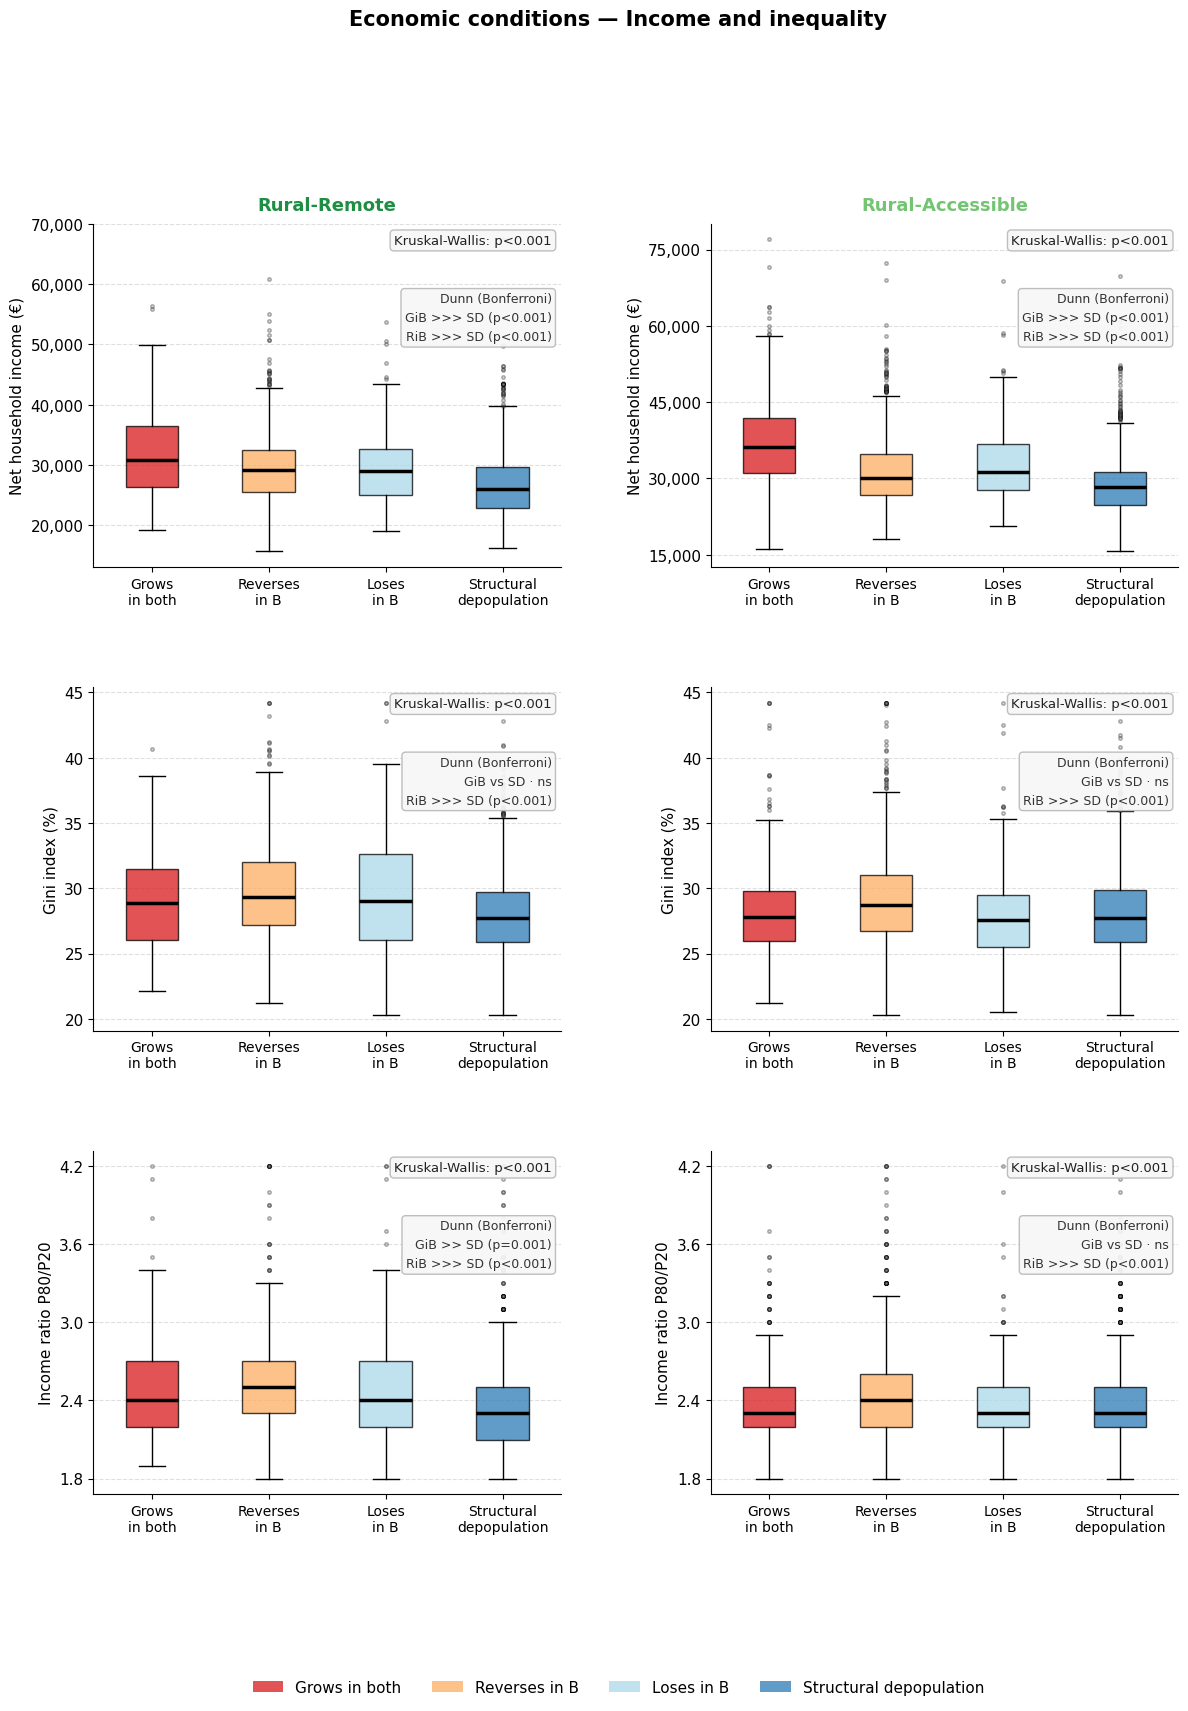

  ✓  00_Fig2_economic_labour_enterprise.png


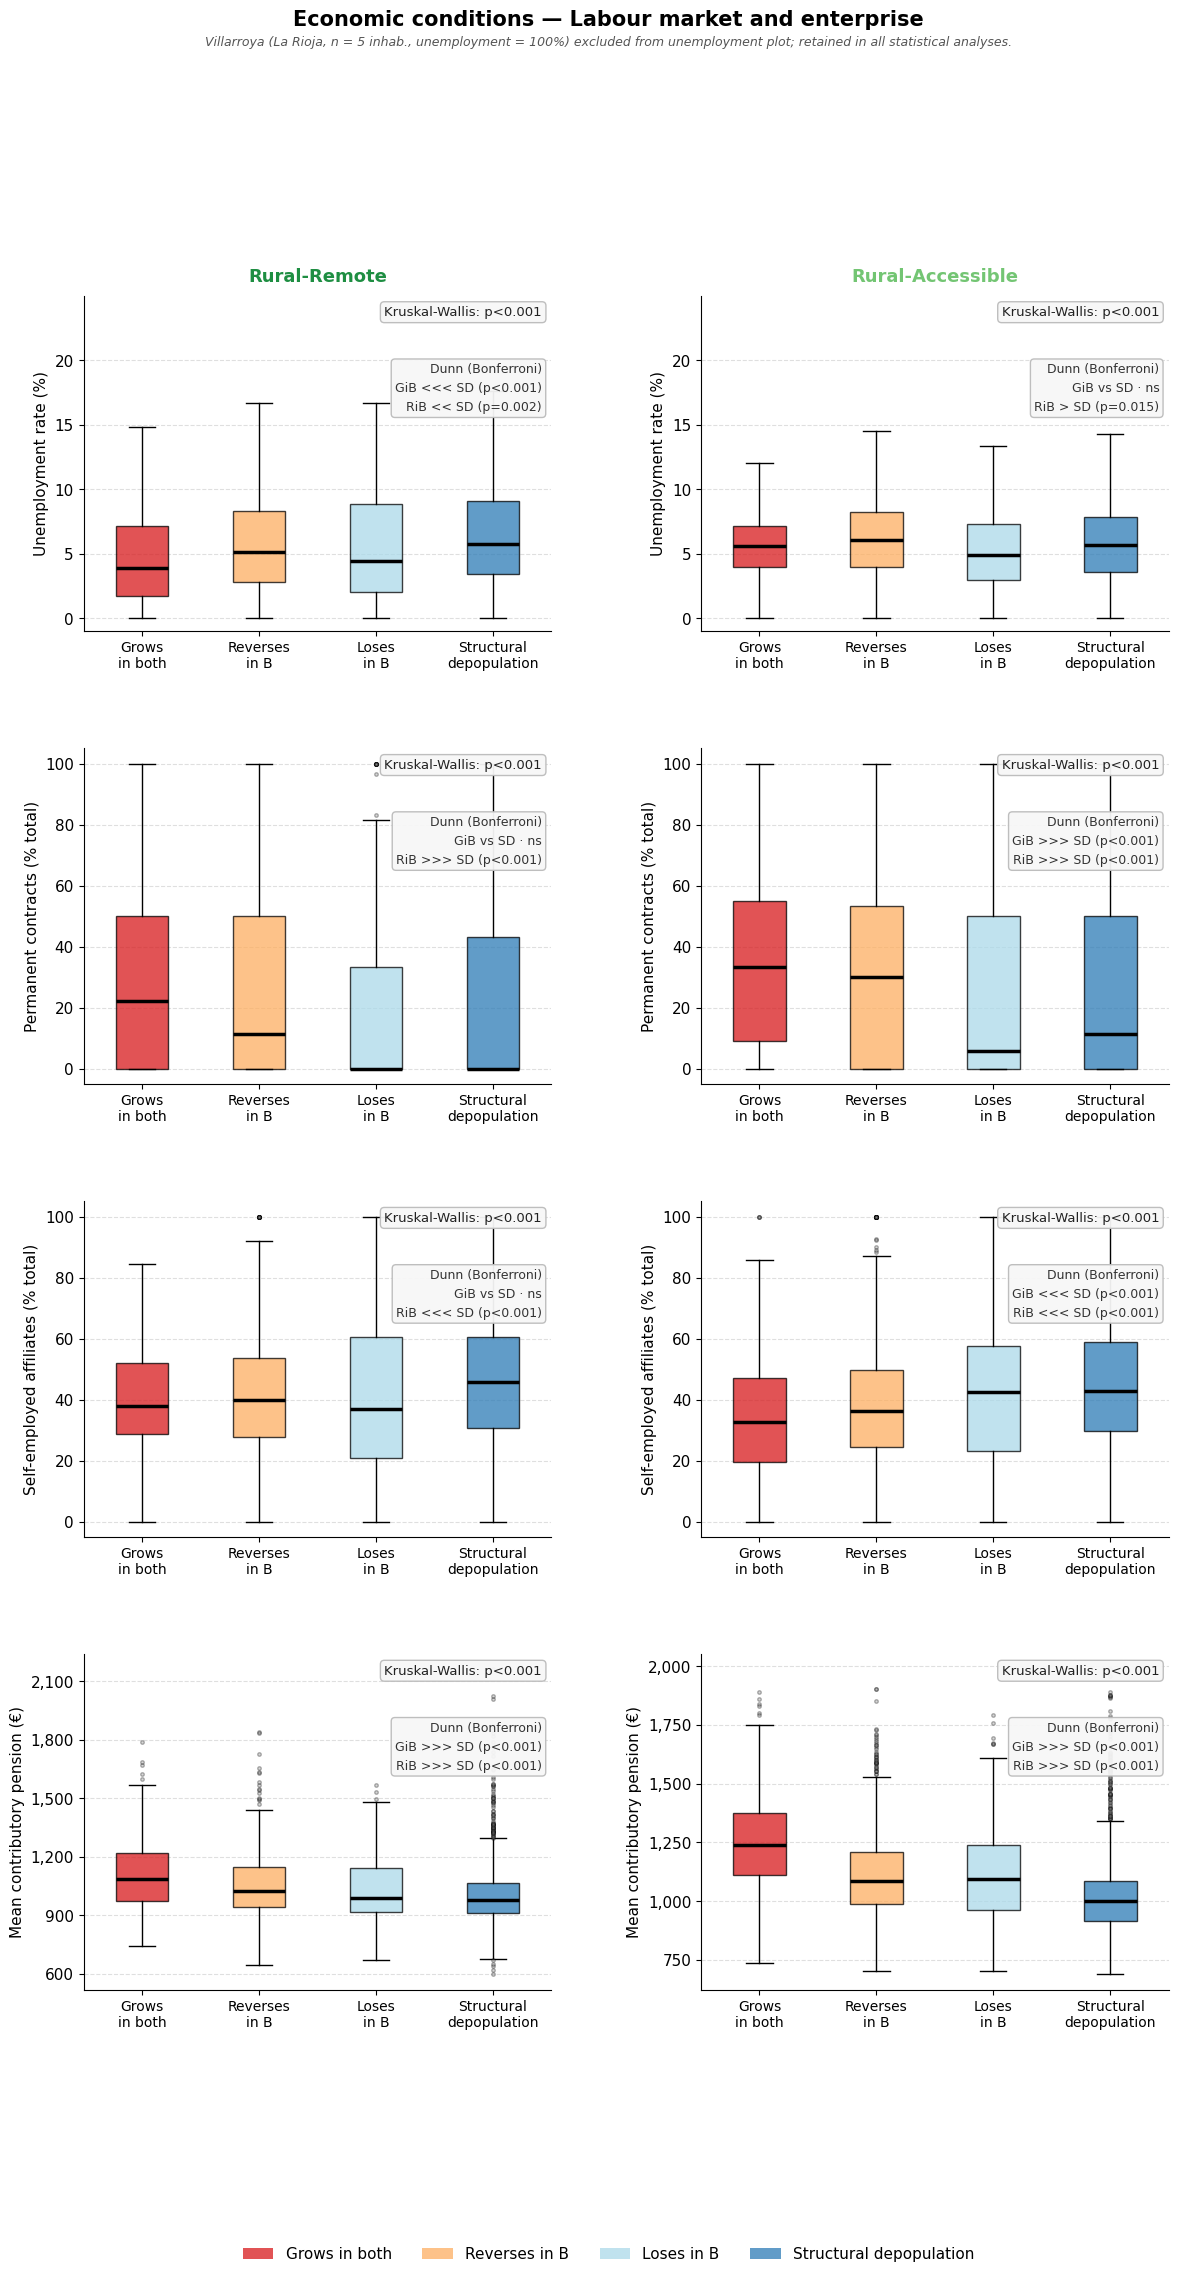

  ✓  00_Fig3_services.png


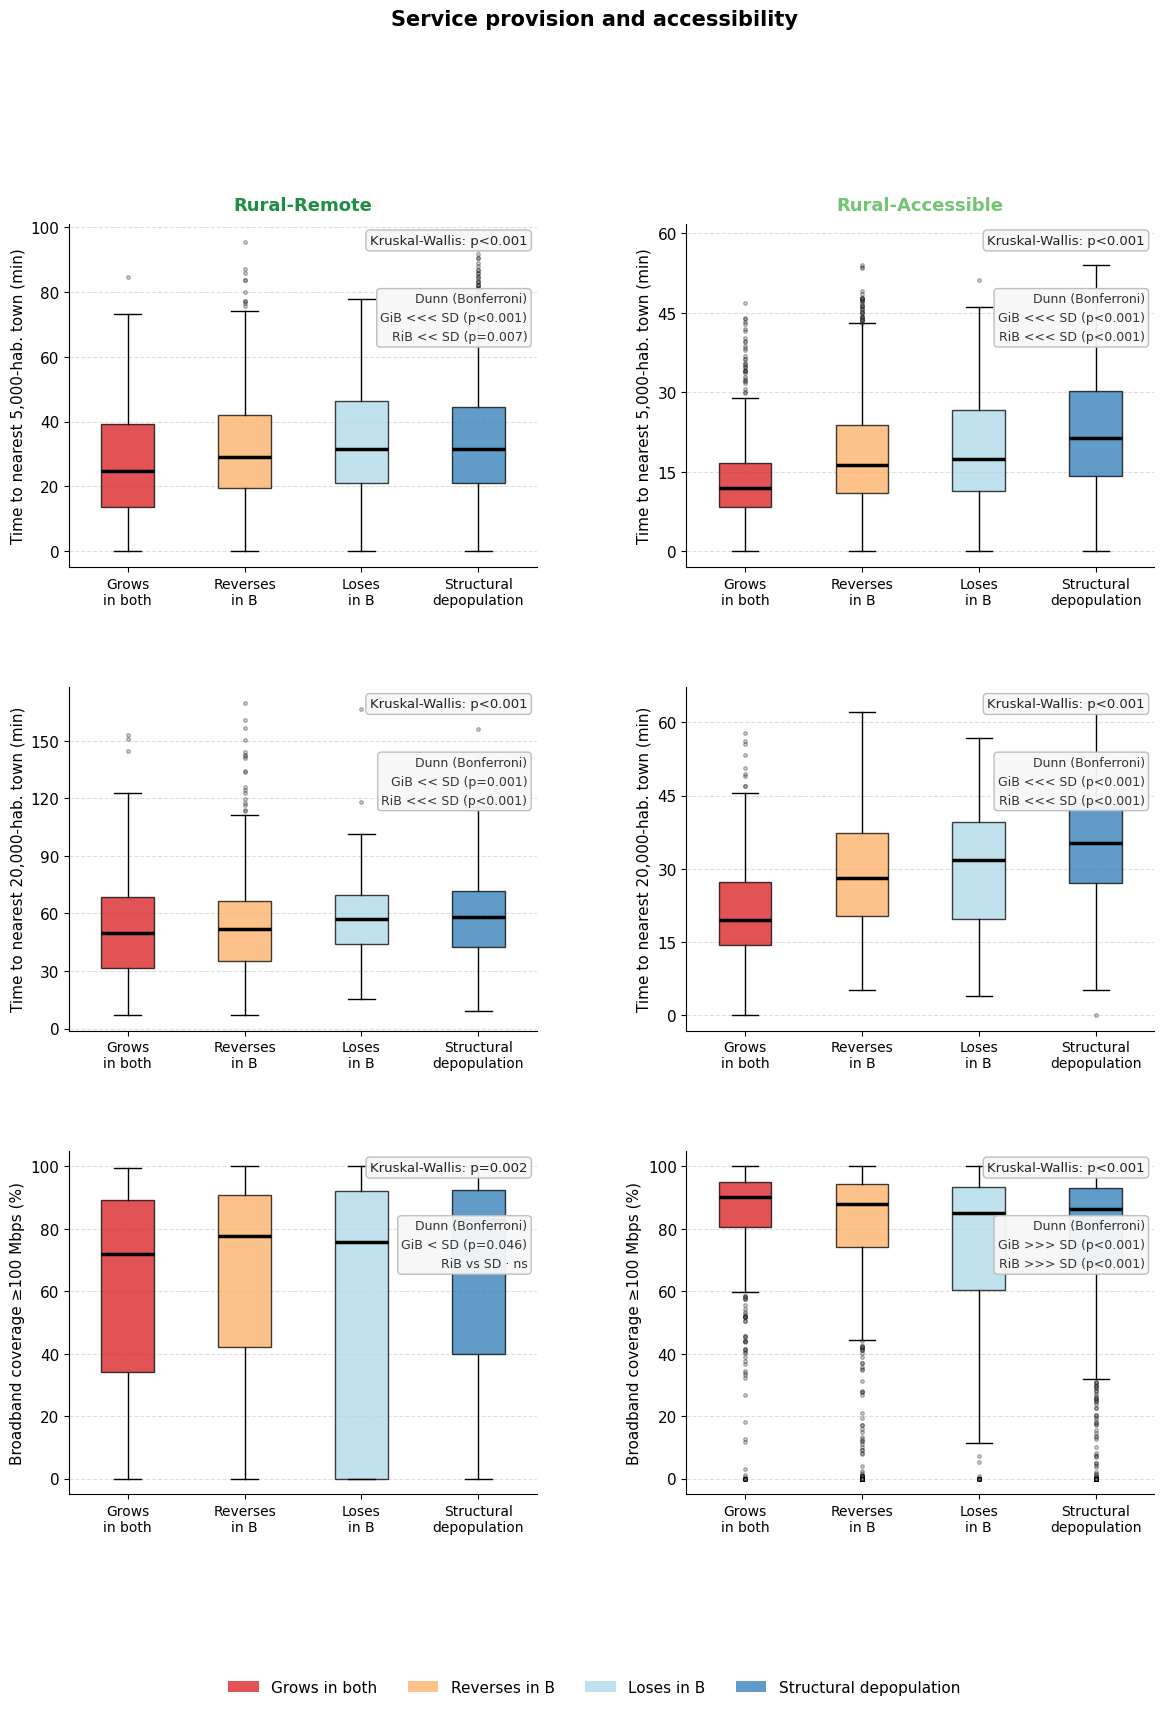

  ✓  00_Fig4_housing.png


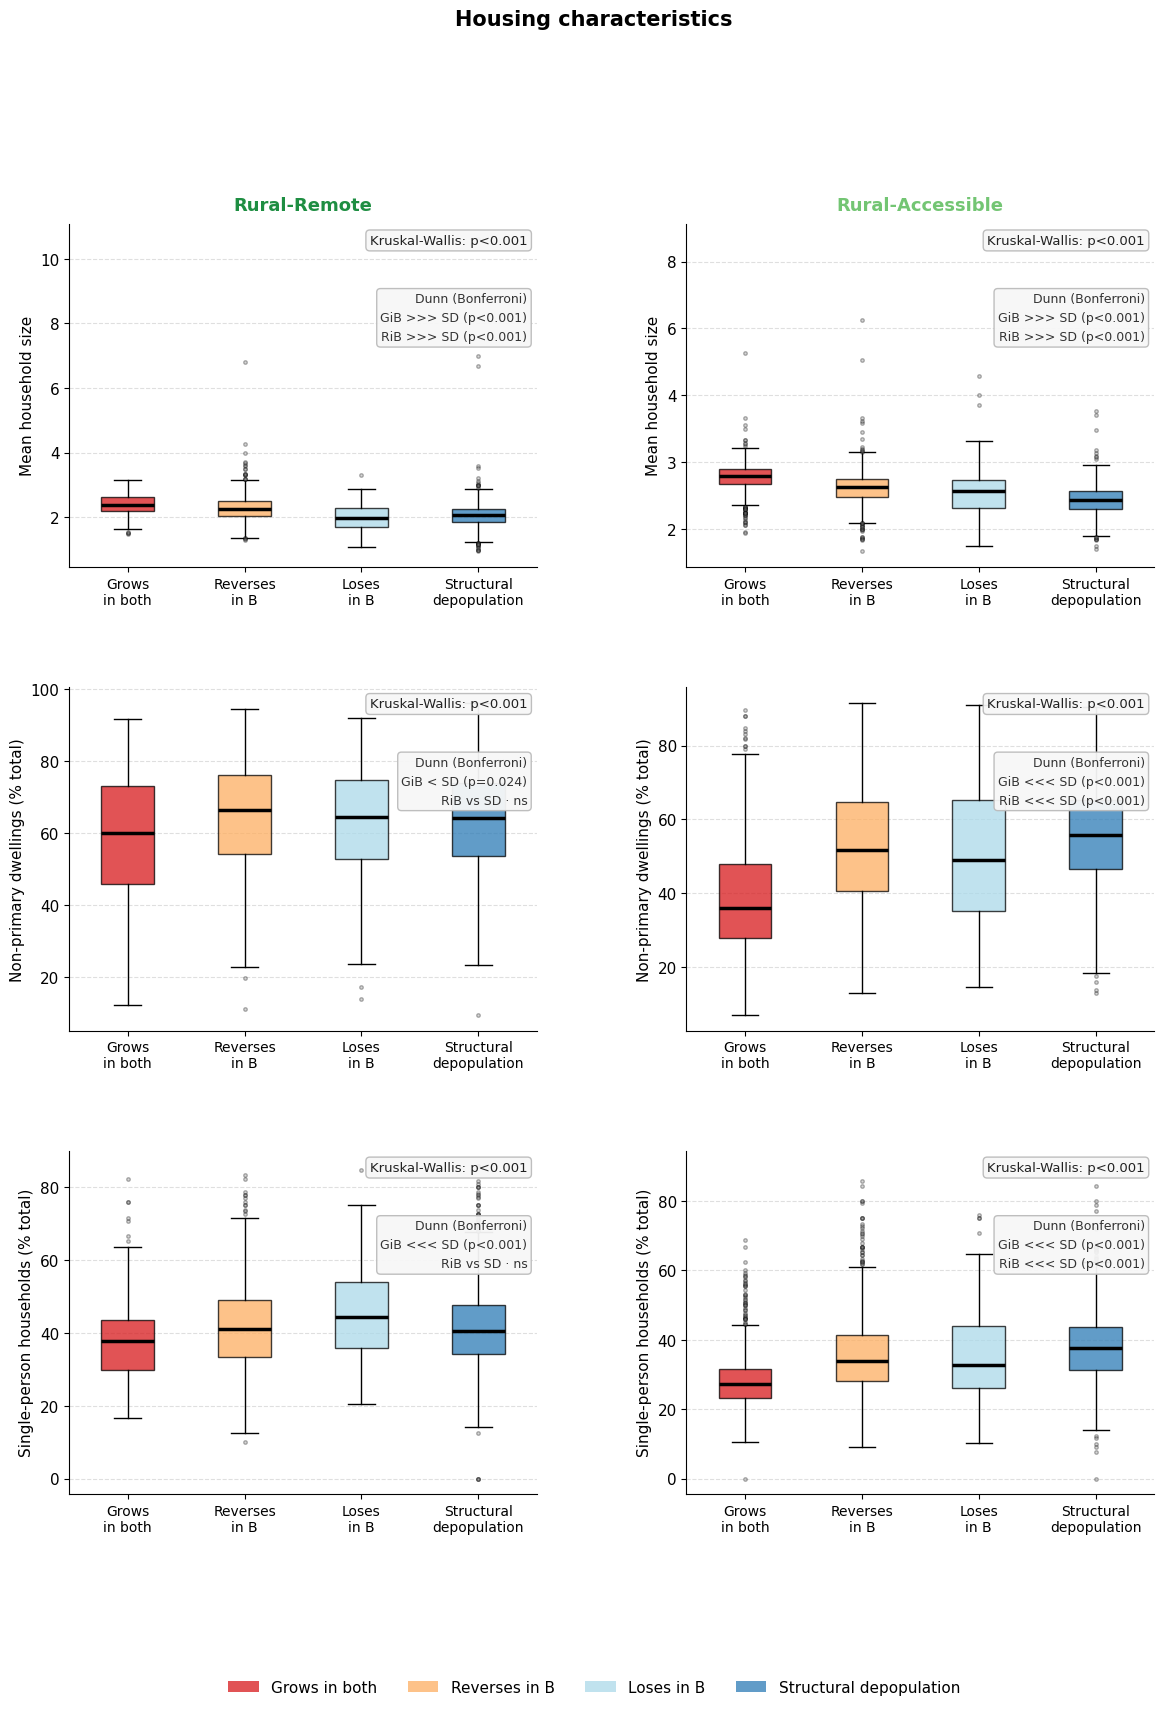

  ✓  00_Fig5_physical_environment.png


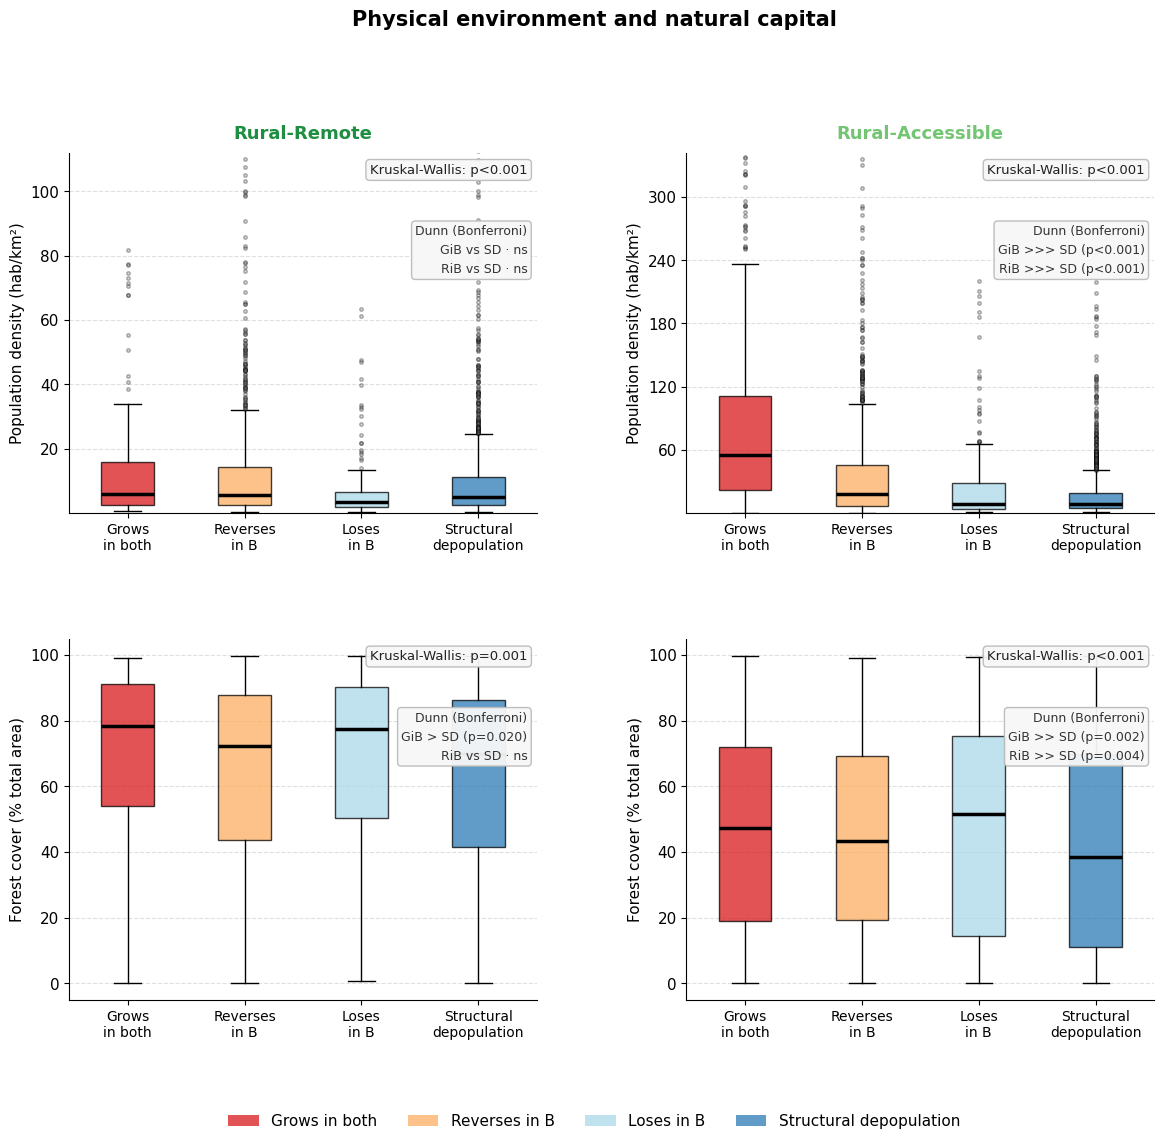


All grouped figures saved to: C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain\figures\p5a_socioeconomic_characterization


In [38]:
# ── 6.4 Grouped figures for paper results section ────────────────────────────
# One figure per thematic group — each row is one variable, two panels per row
# (Rural-Remote left, Rural-Accessible right).
# Files prefixed '00_' to sort first in the figures folder.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

# ── Load pre-computed stat CSVs ───────────────────────────────────────────────
DUNN_CSV = ROOT / 'data/demography/derived/paper1/p5a_dunn_results.csv'
KW_CSV   = ROOT / 'data/demography/derived/paper1/p5a_kruskal_wallis_results.csv'

df_dunn = pd.read_csv(DUNN_CSV, sep=';')
df_kw   = pd.read_csv(KW_CSV,   sep=';')

def _safe_float(x):
    try:
        return float(str(x).replace(',', '.'))
    except:
        return np.nan

def lookup_kw_p(typology, var):
    r = df_kw[(df_kw['typology'] == typology) & (df_kw['variable'] == var)]
    return _safe_float(r['kw_p'].values[0]) if not r.empty else np.nan

def lookup_dunn_p(typology, var, g1, g2):
    r = df_dunn[
        (df_dunn['typology'] == typology) &
        (df_dunn['variable'] == var) &
        (((df_dunn['group1'] == g1) & (df_dunn['group2'] == g2)) |
         ((df_dunn['group1'] == g2) & (df_dunn['group2'] == g1)))
    ]
    return _safe_float(r['p_bonf'].values[0]) if not r.empty else np.nan

def fmt_p(p):
    if np.isnan(p): return '—'
    if p < 0.001:   return 'p<0.001'
    if p < 0.01:    return f'p={p:.3f}'
    return f'p={p:.3f}'

def sig_symbol(p, med_key, med_ref):
    if np.isnan(p) or p >= 0.05:
        return 'ns'
    n = 3 if p < 0.001 else (2 if p < 0.01 else 1)
    sym = '>' if med_key >= med_ref else '<'
    return sym * n

def add_stat_box(ax, typology, var, base_fs):
    fs      = base_fs - 1.5
    fs_dunn = base_fs - 2.0

    kw_p   = lookup_kw_p(typology, var)
    kw_txt = f'Kruskal-Wallis: {fmt_p(kw_p)}'
    ax.text(
        0.98, 0.97, kw_txt,
        transform=ax.transAxes, ha='right', va='top',
        fontsize=fs, color='#222222',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f7f7f7',
                  edgecolor='#bbbbbb', alpha=0.95)
    )

    df_t   = df_master_analysis[df_master_analysis['tipo_goerlich'] == typology]
    med_sd = df_t[df_t['behavioural_group'] == 'Structural depopulation'][var].median()

    lines = ['Dunn (Bonferroni)']
    for g_key, sigla in [('Grows in both', 'GiB'), ('Reverses in B', 'RiB')]:
        p_d     = lookup_dunn_p(typology, var, g_key, 'Structural depopulation')
        med_key = df_t[df_t['behavioural_group'] == g_key][var].median()
        sym     = sig_symbol(p_d, med_key, med_sd)
        p_fmt   = fmt_p(p_d)
        lines.append(f'{sigla} {sym} SD ({p_fmt})' if sym != 'ns' else f'{sigla} vs SD · ns')

    ax.text(
        0.98, 0.80, '\n'.join(lines),
        transform=ax.transAxes, ha='right', va='top',
        fontsize=fs_dunn, color='#333333', linespacing=1.6,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f7f7f7',
                  edgecolor='#bbbbbb', alpha=0.95)
    )


BASE_FONTSIZE_KEY = 11

# ── Fixed Y-axis limits ───────────────────────────────────────────────────────
# Outliers beyond these values are not shown (showfliers=False for these vars).
FIXED_YLIM = {
    'ECONOMIA__PARADOS__POR SEXO__Tasa de paro': 25,
}

# ── Figure group definitions ──────────────────────────────────────────────────
FIGURE_GROUPS = [
    {
        'filename': '00_Fig1_economic_income_inequality',
        'suptitle': 'Economic conditions — Income and inequality',
        'vars': [
            ('Net household income (€)',
             'ECONOMIA__RENTAS__Renta neta media por hogar', None),
            ('Gini index (%)',
             'ECONOMIA__RENTAS__DESIGUALDAD__Índice de Gini (%)', None),
            ('Income ratio P80/P20',
             'ECONOMIA__RENTAS__DESIGUALDAD__Distribución de la renta P80/P20', None),
        ]
    },
    {
        'filename': '00_Fig2_economic_labour_enterprise',
        'suptitle': 'Economic conditions — Labour market and enterprise',
        'vars': [
            ('Unemployment rate (%)',
             'ECONOMIA__PARADOS__POR SEXO__Tasa de paro', None),
            ('Permanent contracts (% total)',
             'ECONOMIA__CONTRATOS__POR DURACIÓN__Contratos indefinidos \n(% s/ Total)', None),
            ('Self-employed affiliates (% total)',
             'ECONOMIA__AFILIADOS__POR SECTOR__Afiliados Régimen Especial (R. E.) T. Autónomos \n(% s/ Total)', None),
            ('Mean contributory pension (€)',
             'ECONOMIA__PENSIONES CONTRIBUTIVAS__Pensión Contributiva Media', None),
        ]
    },
    {
        'filename': '00_Fig3_services',
        'suptitle': 'Service provision and accessibility',
        'vars': [
            ('Time to nearest 5,000-hab. town (min)',
             'SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 5.000 hab. o más, más cercano (minutos)', None),
            ('Time to nearest 20,000-hab. town (min)',
             'SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 20.000 hab. o más, más cercano (minutos)', None),
            ('Broadband coverage ≥100 Mbps (%)',
             'SERVICIOS__INTERNET__Porcentaje cobertura ≥ 100 Mbps (condiciones máxima demanda)', None),
        ]
    },
    {
        'filename': '00_Fig4_housing',
        'suptitle': 'Housing characteristics',
        'vars': [
            ('Mean household size',
             'VIVIENDA__HOGAR__Tamaño medio del hogar', None),
            ('Non-primary dwellings (% total)',
             'VIVIENDA__TIPOS DE VIVIENDAS (familiares)__Viviendas no principales (% s/ total)', None),
            ('Single-person households (% total)',
             'VIVIENDA__HOGAR__Hogares unipersonales \n(% s/ total)', None),
        ]
    },
    {
        'filename': '00_Fig5_physical_environment',
        'suptitle': 'Physical environment and natural capital',
        'vars': [
            ('Population density (hab/km²)',
             'MEDIO FÍSICO__Densidad (hab/km2)', 99),
            ('Forest cover (% total area)',
             'MEDIOAMBIENTE__CAPITAL NATURAL__FORESTAL__Superficie forestal \n(% s/ total)', None),
        ]
    },
]

# ── Render loop ───────────────────────────────────────────────────────────────
print('Generating grouped figures for paper results section...')

for fig_group in FIGURE_GROUPS:

    n_vars = len(fig_group['vars'])
    fig, axes = plt.subplots(
        n_vars, 2,
        figsize=(14, 5.5 * n_vars),
        squeeze=False
    )
    fig.subplots_adjust(hspace=0.35, wspace=0.32)

    if 'labour' in fig_group['filename']:
        fig.text(
            0.5, 0.998,
            'Villarroya (La Rioja, n = 5 inhab., unemployment = 100%) '
            'excluded from unemployment plot; retained in all statistical analyses.',
            ha='center', va='top',
            fontsize=BASE_FONTSIZE_KEY - 2, color='#555555', style='italic'
        )

    for row_idx, var_tuple in enumerate(fig_group['vars']):
        label_en = var_tuple[0]
        var      = var_tuple[1]
        cap_pct  = var_tuple[2] if len(var_tuple) > 2 else None

        if var not in SELECTED_VARS:
            print(f'  SKIP (not in SELECTED_VARS): {label_en}')
            continue

        for col_idx, typology in enumerate([RURAL_REMOTE, RURAL_ACCESSIBLE]):

            ax = axes[row_idx, col_idx]

            df_typ = df_master_analysis[
                df_master_analysis['tipo_goerlich'] == typology
            ].copy()

            if var in PROPORTION_VARS:
                df_typ[var] = df_typ[var] * PROPORTION_VARS[var]

            groups_present = [
                g for g in GROUP_ORDER
                if g in df_typ['behavioural_group'].unique()
            ]

            data_per_group = [
                df_typ[df_typ['behavioural_group'] == g][var].dropna().values
                for g in groups_present
            ]

            # ── Boxplot — no outliers for fixed-ylim vars ────────────────────
            show_fliers = var not in FIXED_YLIM
            bp = ax.boxplot(
                data_per_group,
                patch_artist=True,
                showfliers=show_fliers,
                flierprops=dict(marker='o', markerfacecolor='gray',
                                markersize=2.5, alpha=0.3),
                medianprops=dict(color='black', linewidth=2.5)
            )

            for patch, group in zip(bp['boxes'], groups_present):
                patch.set_facecolor(GROUP_COLORS[group])
                patch.set_alpha(0.75)

            # ── Y-axis cap via percentile (density and similar) ──────────────
            if cap_pct is not None:
                all_vals = np.concatenate([d for d in data_per_group if len(d) > 0])
                ymax     = np.percentile(all_vals, cap_pct)
                ax.set_ylim(bottom=0, top=ymax * 1.05)

            # ── Legacy YLIM_PERCENTILE override (vehicles, etc.) ─────────────
            if var in YLIM_PERCENTILE:
                pct      = YLIM_PERCENTILE[var]
                all_vals = np.concatenate([d for d in data_per_group if len(d) > 0])
                if len(all_vals) > 0:
                    ymax = np.percentile(all_vals, pct)
                    ax.set_ylim(bottom=0, top=ymax * 1.05)

            # ── Fixed Y-axis limit — set after boxplot, outliers already hidden
            if var in FIXED_YLIM:
                ax.set_ylim(bottom=-1, top=FIXED_YLIM[var])

            # ── Column title (first row only) ────────────────────────────────
            typology_short = 'Rural-Remote' if typology == RURAL_REMOTE else 'Rural-Accessible'
            typology_color = TYPOLOGY_COLORS[typology]
            if row_idx == 0:
                ax.set_title(
                    typology_short,
                    fontsize=BASE_FONTSIZE_KEY + 2, fontweight='bold',
                    color=typology_color, pad=10
                )

            # ── X tick labels on ALL rows ────────────────────────────────────
            ax.set_xticklabels(
                [wrap_group_label(g) for g in groups_present],
                fontsize=BASE_FONTSIZE_KEY - 1
            )

            ax.tick_params(axis='y', labelsize=BASE_FONTSIZE_KEY)

            # Auto-select tick format: decimals if range is small
            _all_vals = np.concatenate([d for d in data_per_group if len(d) > 0])
            _yrange   = _all_vals.max() - _all_vals.min() if len(_all_vals) > 0 else 1
            if _yrange < 3:
                ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
                ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
            else:
                ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
                ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))

            ax.grid(axis='y', linestyle='--', alpha=0.4)
            ax.spines[['top', 'right']].set_visible(False)
            ax.set_ylabel(label_en, fontsize=BASE_FONTSIZE_KEY)

            # ── Floating stat annotations ────────────────────────────────────
            add_stat_box(ax, typology, var, base_fs=BASE_FONTSIZE_KEY)

    # ── Shared colour legend ──────────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(facecolor=GROUP_COLORS[g], alpha=0.75, label=g)
        for g in GROUP_ORDER
    ]
    fig.legend(
        handles=legend_patches,
        loc='lower center',
        ncol=4,
        fontsize=BASE_FONTSIZE_KEY,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02)
    )

    # ── Suptitle ─────────────────────────────────────────────────────────────
    fig.suptitle(
        fig_group['suptitle'],
        fontsize=BASE_FONTSIZE_KEY + 4, fontweight='bold', y=1.01
    )

    # ── Save + show inline ───────────────────────────────────────────────────
    save_path = FIG_DIR / f"{fig_group['filename']}.png"
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    print(f'  ✓  {fig_group["filename"]}.png')
    plt.show()

print(f'\nAll grouped figures saved to: {FIG_DIR}')

---
## 7 · Export outputs

In [ ]:
# ── 7.1 Export rural analysis dataset (filtered from master) ────────────────
# Filter master to Rural-Remote + Rural-Accessible via DuckDB SQL.
# This is the clean analysis-ready subset passed to p5b.

identity_cols = [
    'Mun_Code', 'Mun_Name', 'Comarca_Code', 'Comarca_Name',
    'Prov_Code', 'Prov_Name', 'CCAA_Code', 'CCAA_Name',
    'tipo_goerlich', 'size_group', 'Pop_ref',
    'var_acum_pct_A', 'var_acum_pct_B',
    'behavioural_group',
    'lisa_I', 'lisa_p_sim', 'lisa_sig_quad'
]

# Build column list for SQL SELECT
final_cols = [c for c in identity_cols if c in df_master.columns] + [
    v for v in SELECTED_VARS if v in df_master.columns
]
select_clause = ', '.join([f'"{c}"' for c in final_cols])

# Filter via DuckDB SQL — Rural-Remote and Rural-Accessible only
query_rural = f"""
    SELECT {select_clause}
    FROM master
    WHERE tipo_goerlich IN ('{RURAL_REMOTE}', '{RURAL_ACCESSIBLE}')
    ORDER BY tipo_goerlich, behavioural_group, Mun_Code
"""
df_rural_export = con.execute(query_rural).df()

out_rural = DEMO_DERIV / 'p5a_rural_analysis_dataset.csv'
df_rural_export.to_csv(out_rural, sep=';', encoding='utf-8-sig', index=False)

print('Output files summary:')
outputs = [
    DEMO_DERIV / 'p5a_master_dataset.csv',
    DEMO_DERIV / 'p5a_rural_analysis_dataset.csv',
    DEMO_DERIV / 'p5a_selected_variables.csv',
    DEMO_DERIV / 'p5a_descriptive_stats.csv',
    DEMO_DERIV / 'p5a_kruskal_wallis_results.csv',
    DEMO_DERIV / 'p5a_dunn_results.csv',
]
for f in outputs:
    if f.exists():
        size_kb = f.stat().st_size / 1024
        print(f'  ✓  {f.name}  ({size_kb:.1f} KB)')
    else:
        print(f'  ✗  {f.name}  NOT FOUND')

figs = list(FIG_DIR.glob('*.png'))
print(f'\n  Figures in {FIG_DIR.name}/: {len(figs)} files')
for f in sorted(figs):
    print(f'  ✓  {f.name}')

print(f'\nMaster dataset (all typologies): {len(df_master):,} municipalities')
print(f'Rural analysis dataset: {len(df_rural_export):,} municipalities (Remote + Accessible)')


## 8 · Interpretation notes

---

### Methodological notes

**DuckDB join strategy.**
The master dataset is built from `lisa_results_all` (p4 GeoPackage), which contains
all 8,132 Spanish municipalities across the six Goerlich typologies. SIDAMUN variables
are incorporated via a standard tabular LEFT JOIN on `Mun_Code` — no spatial
operations are performed at this stage, as all spatial enrichment was completed in p4.
NULL values in SIDAMUN columns reflect statistical confidentiality suppression, which
disproportionately affects the smallest rural municipalities.

**SIDAMUN demographic block exclusion.**
The DEMOGRAFIA block (population counts, age structure, vegetative balance) is
intentionally excluded from the analysis. These variables are already available in the
p4 layer with higher temporal precision (INE Padrón 1996–2025 vs. SIDAMUN cross-section
2023). Including them would introduce redundant columns and create potential confusion
between data sources within the same pipeline.

**Variable temporality.**
All SIDAMUN variables reflect conditions in approximately 2022–2023, contemporaneous
with the final years of Period B (2018–2025). They characterise the *current
socioeconomic state* of each behavioural group — they do not represent baseline
conditions prior to the inflection point T=2018. Causal inference is not supported
by this cross-sectional design; results should be interpreted as structural
characterisation, not as predictors of demographic reversal.

**Binary service variables.**
All SI/NO binary service columns in the SIDAMUN 2023 snapshot contained no valid
data (0 non-null values). Count variables (número) were used instead, which carry
equivalent presence/absence information plus quantitative variation. The sole exception
is the CRA variable (Municipios con escuela integrada en un centro rural agrupado),
which stored text 'SI'/'NO' and was recoded to binary 1/0. Residual NULL values in
count variables were imputed as 0, reflecting absence of the service.

**Collinearity.**
A single highly collinear pair was identified: Nº centros de Educación Infantil
Segundo Ciclo and Nº centros de Educación Primaria (Spearman ρ = 0.998). The
Infantil variable was excluded; Primaria was retained as the more interpretable
indicator of basic educational infrastructure.

**Kruskal-Wallis vs. ANOVA.**
Kruskal-Wallis (KW) is used in preference to one-way ANOVA because socioeconomic
variables in small rural municipalities present strongly skewed distributions and
numerous outliers, violating the normality assumption required by ANOVA. KW tests
for differences in rank distributions across groups without distributional assumptions,
which is appropriate for this dataset.

**Dunn post-hoc and Bonferroni correction.**
With four behavioural groups, Dunn's test yields six pairwise comparisons per variable.
The Bonferroni correction multiplies each raw p-value by six, yielding an effective
α ≈ 0.008 per comparison. This conservative threshold is appropriate for a published
result where false positives would generate misleading policy interpretations.
A total of 190 out of 306 pairwise comparisons (62%) are significant after correction.

**Rural-Accessible context.**
Rural-Accessible municipalities are almost entirely within 60 km of an urban centre
(98.7%; see p4 results). Group differences in accessibility-related variables —
time to nearest 5,000-hab. municipality, broadband coverage — should therefore be
interpreted cautiously, as the typology itself already conditions accessibility to a
degree not present in Rural-Remote municipalities.

**Six municipalities excluded from statistical analysis.**
Six rural municipalities (5 Rural-Accessible, 1 Rural-Remote) have no behavioural
group assignment due to missing population data at period boundaries
(`var_acum_pct_A` or `var_acum_pct_B` = NaN). These are municipalities with
administrative boundary changes or data gaps in the INE Padrón at the reference
years. They are retained in the master dataset (`p5a_master_dataset.csv`) but
excluded from all statistical tests and figures.

---

### Outputs for p5b

`p5a_rural_analysis_dataset.csv` is the direct input for p5b. It contains the
cleaned, selected variables for the 6,723 Rural-Remote and Rural-Accessible
municipalities, alongside the binary response flags (`is_reverter`, `is_dynamiser`)
needed for the logistic regression models.

`p5a_spearman_correlations.csv` provides Spearman ρ between each variable and the
binary response, computed separately for three strata (rural_remote,
rural_accessible, rural_combined), to inform variable prioritisation in p5b.

`p5a_selected_variables.csv` documents all variable selection decisions —
missing rate, collinearity flag, and correlation with response — for full
methodological transparency.

---

### Known limitations

- SIDAMUN 2023 values may not reflect conditions at T=2018 (the demographic
  inflection point); municipal-level socioeconomic panel data for earlier years
  is not available for most variables.
- Gini index, P80/P20, and rental income variables are suppressed under
  confidentiality thresholds for municipalities below a minimum population,
  disproportionately affecting the smallest Rural-Remote municipalities
  (<1,000 inhabitants). This introduces systematic missingness in precisely
  the most structurally deprived segment of the sample.
- Service count variables (pharmacies, bank branches, primary schools) reflect
  absolute counts, not per-capita rates. In very small municipalities a single
  facility serving several thousand inhabitants produces the same value as one
  serving fewer than a hundred. Interpretation should account for population size.
- The distance variables (time to nearest 5,000-hab. and 20,000-hab. municipality)
  are taken from SIDAMUN and reflect road travel time, not straight-line distance.
  They are more informative than Euclidean proxies but may not fully capture
  effective accessibility in mountain or island municipalities.